# AIMLC ZG5536 — Large Language Models for Generative AI
#### Problem Statement 1A — Building & Fine-Tuning a Domain-Specific LLM
#### End-to-End Pipeline: Continual Pre-Training  to  QLoRA Instruction Fine-Tuning.

**Group 157**



## Student Details

| Name | BITS ID | Email |
|---|---|---|
| Pradeep Anand C | 2025ae05886 | 2025ae05886@wilp.bits-pilani.ac.in |
| Dron Adhikari | 2025ae05184 | 2025ae05184@wilp.bits-pilani.ac.in |
| Pravallika Donthala | 2025ae05181 | 2025ae05181@wilp.bits-pilani.ac.in |
| B Devchandraaj | 2025ae05469 | 2025ae05469@wilp.bits-pilani.ac.in |

## Pod Setup (BITS Prayogshala / Kubeflow)

> **Disclaimer - create the volume first.** When you create the notebook server, the workspace volume must be a **new volume named `group157`, mounted at `/home/group157/`**. All outputs, the repo clone and the `venv` live on this volume, and the notebook's setup cell is set to `/home/group157`. If the volume has another name or mount path, change `VOLUME_OVERRIDE` in the setup cell to match.
>
> Server settings used: workspace volume `group157` (15 Gi, `nfs-client`, ReadWriteOnce, mount path `/home/group157`); CPU 7 min / 8 max; memory 15 Gi min / 16 Gi max; 1 NVIDIA GPU; toleration group `NVIDIA A100 GPU Node`; shared memory on.

Do the steps below once, in a pod Terminal, **before** opening the notebook (they cannot run from inside the notebook, because JupyterLab must see the repo first).

**1. Clone the repo onto the group volume:**

```
cd /home/group157
git clone https://github.com/devcoderb/llm-assignment-1a-finance-corpus.git
```

**2. Build the environment from `/home/group157`** (run it from that folder, so `./venv` is created on the volume; installs the pinned course packages and registers the kernel `Python (LLM venv)`; about 2-4 minutes):

```
cd /home/group157
bash llm-assignment-1a-finance-corpus/kubeflow/setup_env.sh
./venv/bin/python llm-assignment-1a-finance-corpus/kubeflow/check_env.py
```

After a pod restart the `venv` persists, but the kernel registration does not: re-run the `setup_env.sh` command above (fast) if the kernel is missing from the menu.

**3. Link the repo into the JupyterLab folder:**

```
ln -s /home/group157/llm-assignment-1a-finance-corpus ~/llm-assignment-1a-finance-corpus
```

**4. Open the notebook:** *File -> Open from Path...* and enter `llm-assignment-1a-finance-corpus/Assignment-1a-v5.ipynb`.

**5. Select the kernel** `Python (LLM venv)`, then run all cells. Later updates: `git pull` inside the cloned folder.

All outputs (`domain_corpus/`, `cpt_model/`, `qlora_finance_adapter/`, JSONL files) are written to `/home/group157`, the persistent group volume.

In [2]:
import torch
import sys

print("Python :", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA    :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU     :", torch.cuda.get_device_name(0))
    print(
        "VRAM    :",
        round(
            torch.cuda.get_device_properties(0).total_memory
            / 1024**3,
            2
        ),
        "GB"
    )

assert torch.cuda.is_available(), "GPU is not available."

print("\n>> [OK] GPU environment ready.")

Python : 3.11.11
PyTorch: 2.5.1+cu124
CUDA    : True
GPU     : NVIDIA A100-SXM4-80GB
VRAM    : 79.15 GB

>> [OK] GPU environment ready.


## Implementation Pipeline

This notebook implements the complete **Continued Pretraining (CPT) and QLoRA fine-tuning pipeline** for the finance domain.

### Part A: Continued Pretraining

**Finance PDFs**  
↓  
**Step 1 — Data Collection, Extraction and Cleaning**  
30 domain PDFs → page-by-page text extraction → normalization → length filtering → deduplication → English-language filtering → cleaned `.txt` corpus

↓  
**Step 2 — Tokenization and Packed Dataset**  
SmolLM2-360M tokenizer → BOS/EOS document boundaries → token concatenation → 8,192-token packed sequences → Parquet dataset

↓  
**Step 3 — Base Model and Baseline**  
Load SmolLM2-360M → inspect architecture and parameter counts → generate responses for 10 finance-domain prompts (5 instruction-style, 5 completion-style) before CPT

↓  
**Step 4 — Continued Pretraining (CPT)**  
Convert packed corpus into GPU-compatible 1,024-token training blocks → ~90/10 train/held-out split → full-parameter CPT → capture training loss → analyse loss curve → save CPT model

↓  
**Step 5 — CPT Evaluation**  
Evaluate held-out finance data → calculate perplexity → compare base vs CPT model → repeat the same domain prompts → check general-prompt performance for catastrophic forgetting

---

### Part B: QLoRA Instruction Fine-Tuning

**Cleaned Finance Corpus**  
↓  
**B1 — Instruction Dataset**  
Create grounded instruction-response examples → save JSONL → 80/20 train/evaluation split

↓  
**B2 — QLoRA Fine-Tuning**  
Load model in 4-bit → attach LoRA adapters → supervised fine-tuning using the selected QLoRA configuration

↓  
**B3 — QLoRA Evaluation**  
Run the same finance-domain prompts → compare responses with the base/CPT results → record observations


Assignment mapping:

Steps 1–5 implement Part A (Continued Pretraining), while Steps 6–8 implement Part B (QLoRA Fine-Tuning). Step 9 verifies the submission artifacts.

---

## Step 1: Data Collection, Extraction and Cleaning

This step prepares the domain-specific corpus for continued pretraining.

The selected corpus focuses on **Indian Financial Markets and Digital Payments** and consists of publications from SEBI, RBI, and NPCI.

The following stages:
- Retrieve and validate the selected source PDFs.
- Extract text from every PDF page-by-page.
- Inspect the extracted text for extraction quality.
- Normalize whitespace and apply length filtering.
- Remove exact duplicate documents.
- Retain English-language documents.
- Validate the deduplication and language-filtering logic using separate test documents.
- Save the resulting cleaned documents as the final domain corpus.

Document counts before and after each required cleaning operation are reported to measure the effect of the cleaning pipeline.

---

#### Setup and Stage 1: Persistent Folder, Packages and Corpus

Run with the **Python (LLM venv)** kernel. `VOLUME_OVERRIDE` changes the data-volume mount if needed.

**Domain:** Indian Capital Markets, Banking and Digital Payments

The corpus was selected to provide three complementary areas of Indian finance:

- **Capital Markets:** SEBI material covering equity derivatives trader studies, securities buy-backs and takeovers, listing obligations and disclosures (LODR), infrastructure investment trusts, municipal debt securities, and the investor protection fund.
- **Banking:** RBI Directions on Asset Reconstruction Companies (ARCs) covering their governance, KYC, credit-information reporting, and the treatment of wilful and large defaulters, together with the RBI Master Direction on Payment Aggregators.
- **Digital Payments:** RBI and NPCI material covering UPI, retail payment statistics, payment systems, Payments Vision 2025, and India's payment-system development.

These documents were selected because they are domain-specific publications from Indian financial institutions and contain terminology, regulations, statistics, and financial concepts suitable for continued pretraining.

The corpus contains **30 PDF documents**. This stage retrieves the documents and verifies that all 30 files are available before text extraction begins.

In [3]:
# Setup: persistent folder, package installation, corpus
import os, sys, subprocess, importlib.util
from pathlib import Path

# ---- Override field: set to your data-volume mount if it is not /home/05469 ----
VOLUME_OVERRIDE = "/home/group157"   # group 157 workspace volume; None = use the default below
DEFAULT_VOLUME = "/home/05469"
# --------------------------------------------------------------------------------

# 1. Work on the persistent data volume (not the temporary /home/jovyan)
VOLUME = Path(VOLUME_OVERRIDE or DEFAULT_VOLUME)
assert VOLUME.exists(), f"Mount not found: {VOLUME}. Set VOLUME_OVERRIDE to your data-volume path (check with: df -h | grep home)."
os.chdir(VOLUME)
assert not str(Path.cwd()).startswith("/home/jovyan"), "Still on temporary home - set VOLUME_OVERRIDE."
print("Working directory:", Path.cwd())

# 2. Kernel check + packages (use the 'Python (LLM venv)' kernel)
from importlib.metadata import version, PackageNotFoundError
print("Python:", sys.executable)
if "venv" not in sys.executable:
    print(">> WARNING: not the venv kernel. Kernel -> Change Kernel -> 'Python (LLM venv)', then restart.")

print("\nPackage check")
for mod, pip_name in {"pymupdf": "pymupdf", "pandas": "pandas", "graphviz": "graphviz",
                      "langdetect": "langdetect", "transformers": "transformers", "pyarrow": "pyarrow"}.items():
    status = "already installed"
    if importlib.util.find_spec(mod) is None:
        print(f"  [..] installing {pip_name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])
        importlib.invalidate_caches()
        status = "installed now"
    try:
        v = version(pip_name)
    except PackageNotFoundError:
        v = "?"
    print(f"  [OK] {pip_name:<14} {v:<10} ({status})")

# 3. Corpus: clone once, otherwise reuse (or use PDFs you uploaded by hand)
REPO_URL = "https://github.com/devcoderb/llm-assignment-1a-finance-corpus.git"
REPO_DIR = Path.cwd() / "llm-assignment-1a-finance-corpus"
if not REPO_DIR.exists():
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(REPO_DIR)], check=False)

PDF_ROOT = REPO_DIR / "data" / "corpus" / "v1" / "Finance"
pdf_files = sorted(p for p in PDF_ROOT.rglob("*.pdf") if "Tests" not in p.parts)
expected_pdf_count = len(pdf_files)
print(f"\nPDFs found: {expected_pdf_count}")
for i, p in enumerate(pdf_files, 1):
    print(f"{i:02d}. {p.relative_to(PDF_ROOT)}")
assert expected_pdf_count > 0, f"No PDFs in {PDF_ROOT} - upload them there if the clone failed."


Working directory: /home/group157
Python: /home/group157/venv/bin/python

Package check
  [OK] pymupdf        1.28.2     (already installed)
  [OK] pandas         2.2.3      (already installed)
  [OK] graphviz       0.21       (already installed)
  [OK] langdetect     1.0.9      (already installed)
  [OK] transformers   4.46.3     (already installed)
  [OK] pyarrow        25.0.1     (already installed)

PDFs found: 30
01. Banking/RBI - Asset Reconstruction Companies Directions 2025.pdf
02. Banking/RBI - Asset Reconstruction Companies – Credit Information Reporting Directions 2025.pdf
03. Banking/RBI - Asset Reconstruction Companies – Know Your Customer Directions 2025.pdf
04. Banking/RBI - Asset Reconstruction Companies – Treatment of Wilful Defaulters and Large Defaulters Directions 2025.pdf
05. Banking/RBI - Digital Lending Guidelines.pdf
06. Banking/RBI - Financial Stability Report Dec 2025.pdf
07. Banking/RBI - Master Circular on IRAC norms on asset classification and provisioning.

### Stage 2: Page-Level PDF Extraction with Prose Filter

**Purpose:** Convert the source finance PDFs into machine-readable text, dropping table/glossary pages and repeated headers/footers.

Per document:
1. **Boilerplate stripping** - lines that repeat (digits ignored) on at least 25% of a document's pages are removed (running headers/footers), as are bare page-number lines.
2. **Exact page dedup** - identical pages (blank/title duplicates) are skipped.
3. **Prose filter** (a page is dropped when):

| Rule | Condition | What it catches |
|------|-----------|-----------------|
| `numeric_heavy` | > 45% of lines are numbers/symbols only **and** < 10 sentences | data grids |
| `short_line_heavy` | > 70% of lines have <= 4 words **and** < 8 sentences | glossaries, label columns |
| `no_prose` | < 2 sentences | pages with no running text |

Sentence-count gating keeps narrow-column pages that are real prose (v2 wrongly dropped e.g. RBI Annual Report p.220).

In [4]:
### Stage 2: Page-level extraction with boilerplate stripping and prose filter
import re, hashlib, collections
import pymupdf
import pandas as pd

EXTRACTED_DIR = Path("domain_corpus/raw")
EXTRACTED_DIR.mkdir(parents=True, exist_ok=True)

NUMERIC_LINE = re.compile(r"^[\d\s.,%()\-–/₹$:+]+$")
PAGE_NO_LINE = re.compile(r"^\s*(\d{1,4}|[ivxlcdm]{1,6})\s*$", re.I)
BOILERPLATE_MIN_PAGES = 6      # skip boilerplate detection for very short documents
BOILERPLATE_FRACTION = 0.25    # line repeated on >= 25% of pages -> header/footer


def norm_line(line: str) -> str:
    return re.sub(r"\d+", "#", re.sub(r"\s+", " ", line.strip().lower()))


def find_boilerplate(page_texts):
    """Lines (digits ignored) repeated on many pages of ONE document = headers/footers."""
    if len(page_texts) < BOILERPLATE_MIN_PAGES:
        return set()
    counts = collections.Counter()
    for t in page_texts:
        counts.update({norm_line(l) for l in t.splitlines() if l.strip()})
    limit = max(4, BOILERPLATE_FRACTION * len(page_texts))
    return {l for l, n in counts.items() if n >= limit and 3 < len(l) < 150}


def strip_page(text, boilerplate):
    kept, removed = [], 0
    for l in text.splitlines():
        if not l.strip():
            kept.append(l); continue
        if PAGE_NO_LINE.match(l) or norm_line(l) in boilerplate:
            removed += 1; continue
        kept.append(l)
    return "\n".join(kept).strip(), removed


def count_sentences(text):
    flat = re.sub(r"\s+", " ", text)
    # split after . ! ? ; followed by space (a decimal like 8.5 has no space, so it is not split)
    parts = re.split(r"(?<=[.!?;])\s+", flat)
    return sum(1 for s in parts if len(s.split()) >= 8 and s.rstrip().endswith((".", "!", "?", ";")))


def score_page(text: str) -> dict:
    """Score one (already boilerplate-stripped) page. Returns signals + keep flag."""
    if not text or len(text.strip()) < 80:
        return {"numeric_ratio": 0, "short_line_ratio": 0, "sentence_count": 0,
                "keep": False, "reason": "too_short"}
    lines = [l for l in text.splitlines() if l.strip()]
    numeric_ratio = sum(bool(NUMERIC_LINE.match(l)) for l in lines) / len(lines)
    short_line_ratio = sum(len(l.split()) <= 4 for l in lines) / len(lines)
    sentence_count = count_sentences(text)

    if numeric_ratio > 0.45 and sentence_count < 10:
        keep, reason = False, "numeric_heavy"
    elif short_line_ratio > 0.70 and sentence_count < 6:
        keep, reason = False, "short_line_heavy"
    elif sentence_count < 2:
        keep, reason = False, "no_prose"
    else:
        keep, reason = True, "pass"
    return {"numeric_ratio": round(numeric_ratio, 3),
            "short_line_ratio": round(short_line_ratio, 3),
            "sentence_count": sentence_count, "keep": keep, "reason": reason}


def page_hash(text: str) -> str:
    return hashlib.md5(re.sub(r"\s+", " ", text.lower().strip()).encode()).hexdigest()


seen_page_hashes: set = set()
extraction_stats, page_filter_log = [], []

for pdf_path in pdf_files:
    doc = pymupdf.open(pdf_path)
    n_pages = len(doc)
    raw_pages = [p.get_text("text").strip() for p in doc]
    doc.close()

    boilerplate = find_boilerplate([t for t in raw_pages if t])
    kept_pages, c = [], collections.Counter()

    for page_number, raw_text in enumerate(raw_pages, start=1):
        if not raw_text:
            c["empty"] += 1
            page_filter_log.append({"document": pdf_path.name, "page": page_number,
                                    "action": "empty", "reason": "empty_page"})
            continue
        ph = page_hash(raw_text)
        if ph in seen_page_hashes:
            c["deduped"] += 1
            page_filter_log.append({"document": pdf_path.name, "page": page_number,
                                    "action": "dedup_drop", "reason": "duplicate_page"})
            continue
        seen_page_hashes.add(ph)

        text, removed = strip_page(raw_text, boilerplate)
        c["boilerplate_lines"] += removed
        score = score_page(text)
        page_filter_log.append({"document": pdf_path.name, "page": page_number,
                                "action": "keep" if score["keep"] else "drop",
                                "reason": score["reason"],
                                "numeric_ratio": score.get("numeric_ratio"),
                                "short_line_ratio": score.get("short_line_ratio"),
                                "sentence_count": score.get("sentence_count")})
        if score["keep"]:
            kept_pages.append(text)
        else:
            c["dropped"] += 1

    full_text = "\n\n".join(kept_pages)
    output_path = EXTRACTED_DIR / f"{pdf_path.stem}.txt"
    output_path.write_text(full_text, encoding="utf-8")

    extraction_stats.append({
        "document": pdf_path.name, "total_pages": n_pages,
        "empty_pages": c["empty"], "deduped_pages": c["deduped"],
        "dropped_pages_filter": c["dropped"], "kept_pages": len(kept_pages),
        "boilerplate_lines_removed": c["boilerplate_lines"],
        "raw_characters": sum(len(t) for t in raw_pages),
        "kept_characters": len(full_text), "output_file": str(output_path),
    })

extraction_df = pd.DataFrame(extraction_stats)
filter_log_df = pd.DataFrame(page_filter_log)

print("Stage 2: PDF Extraction with Page-Level Filter")
print("-" * 55)
display(extraction_df[["document", "total_pages", "empty_pages", "deduped_pages",
                       "dropped_pages_filter", "kept_pages",
                       "boilerplate_lines_removed", "raw_characters", "kept_characters"]])

total_all = len(filter_log_df)
print("\nPage Filter Summary")
print("-------------------")
print(f"Total pages seen         : {total_all:,}")
for act, label in [("empty", "Empty (no text)"), ("dedup_drop", "Duplicate pages"),
                   ("drop", "Dropped (noise/table)"), ("keep", "Kept (prose)")]:
    print(f"  {label:<23}: {(filter_log_df['action'] == act).sum():,}")
kept_n = (filter_log_df["action"] == "keep").sum()
print(f"  Page retention         : {kept_n / max(total_all, 1) * 100:.1f}%")
print(f"  Character retention    : {extraction_df['kept_characters'].sum() / extraction_df['raw_characters'].sum() * 100:.1f}%")
print(f"  Header/footer lines removed: {extraction_df['boilerplate_lines_removed'].sum():,}")

drop_reasons = filter_log_df[filter_log_df["action"] == "drop"]["reason"].value_counts()
if not drop_reasons.empty:
    print("\nDrop reasons (noise filter):")
    for reason, count in drop_reasons.items():
        print(f"  {reason:<25} : {count:,}")

print(f"\n>> [OK] Extraction complete. {len(extraction_df)} documents written to {EXTRACTED_DIR}/")

# Guard: a document with very few pages is usually a press-release summary, not the full report
short_docs = extraction_df[extraction_df["total_pages"] < 5]
if len(short_docs):
    print("\n>> [WARNING] Documents with fewer than 5 pages (summary or press-release PDF?):")
    for _, r in short_docs.iterrows():
        print(f"   {r['document']} ({r['total_pages']} page(s))")


Stage 2: PDF Extraction with Page-Level Filter
-------------------------------------------------------


,document,total_pages,empty_pages,deduped_pages,dropped_pages_filter,kept_pages,boilerplate_lines_removed,raw_characters,kept_characters
0,RBI - Asset Reconstruction Companies Direction...,78,0,0,4,74,107,134713,130404
1,RBI - Asset Reconstruction Companies – Credit ...,69,0,0,27,42,582,106926,74379
2,RBI - Asset Reconstruction Companies – Know Yo...,80,0,0,2,78,80,164439,163883
3,RBI - Asset Reconstruction Companies – Treatme...,13,0,0,1,12,66,17891,17293
4,RBI - Digital Lending Guidelines.pdf,12,0,0,1,11,114,21540,20605
5,RBI - Financial Stability Report Dec 2025.pdf,185,2,1,24,158,5133,446830,383717
6,RBI - Master Circular on IRAC norms on asset c...,77,0,0,1,76,200,170440,168834
7,RBI - Master Direction on Regulation of Paymen...,26,0,0,3,23,28,44736,43829
8,RBI - Trend and Progress of Banking in India D...,220,6,0,35,179,8653,591946,488107
9,Profitability of Individual Traders in the Equ...,91,0,0,21,70,753,171695,139704



Page Filter Summary
-------------------
Total pages seen         : 3,588
  Empty (no text)        : 23
  Duplicate pages        : 1
  Dropped (noise/table)  : 418
  Kept (prose)           : 3,146
  Page retention         : 87.7%
  Character retention    : 90.4%
  Header/footer lines removed: 26,847

Drop reasons (noise filter):
  short_line_heavy          : 249
  numeric_heavy             : 101
  no_prose                  : 50
  too_short                 : 18

>> [OK] Extraction complete. 30 documents written to domain_corpus/raw/


In [5]:
# Stage 2A: Filter diagnostic: inspect dropped pages per document

print("Stage 2A: Page Filter Diagnostic")
print("-" * 35)
print()

for doc_name in extraction_df["document"].unique():
    doc_log = filter_log_df[filter_log_df["document"] == doc_name]
    kept = (doc_log["action"] == "keep").sum()
    dropped = (doc_log["action"] == "drop").sum()
    deduped = (doc_log["action"] == "dedup_drop").sum()
    total = len(doc_log)

    print(f"{doc_name[:55]:<55}")
    print(f"   kept={kept}  dropped={dropped}  deduped={deduped}  total={total}")

    # Show the 3 highest-scoring dropped pages for operator review
    dropped_pages = doc_log[
        (doc_log["document"] == doc_name) & (doc_log["action"] == "drop")
    ].head(3)

    if not dropped_pages.empty and "numeric_ratio" in dropped_pages.columns:
        for _, row in dropped_pages.iterrows():
            print(f"     page {row['page']:>4}  reason={row['reason']:<20}", end="")
            if pd.notna(row.get("numeric_ratio")):
                print(f"  numeric={row['numeric_ratio']:.2f}  short_ln={row['short_line_ratio']:.2f}  sents={row['sentence_count']}")
            else:
                print()
    print()

print(">> Tip: If a document has 0 kept pages it will be removed by the length filter.")
print(">> Tune score_page() thresholds if legitimate pages are being dropped.")

Stage 2A: Page Filter Diagnostic
-----------------------------------

RBI - Asset Reconstruction Companies Directions 2025.pd
   kept=74  dropped=4  deduped=0  total=78
     page   53  reason=short_line_heavy      numeric=0.00  short_ln=0.93  sents=4.0
     page   60  reason=no_prose              numeric=0.00  short_ln=0.50  sents=1.0
     page   69  reason=no_prose              numeric=0.00  short_ln=0.47  sents=1.0

RBI - Asset Reconstruction Companies – Credit Informati
   kept=42  dropped=27  deduped=0  total=69
     page    2  reason=short_line_heavy      numeric=0.00  short_ln=1.00  sents=0.0
     page   29  reason=no_prose              numeric=0.00  short_ln=0.38  sents=1.0
     page   30  reason=short_line_heavy      numeric=0.00  short_ln=0.95  sents=0.0

RBI - Asset Reconstruction Companies – Know Your Custom
   kept=78  dropped=2  deduped=0  total=80
     page   42  reason=too_short             numeric=0.00  short_ln=0.00  sents=0.0
     page   53  reason=no_prose           

### Page Filter Observation

The page-level filter examined 3,588 pages from the 30 PDFs and kept 3,146 of them (87.7% of pages, 90.4% of characters).

| Pages | Count |
|---|---|
| Empty (no text) | 23 |
| Duplicate pages | 1 |
| Dropped as noise or tables | 418 |
| Kept as prose | 3,146 |

The 418 dropped pages were removed for four reasons:

| Reason | Pages | Share of dropped | Typical content |
|---|---|---|---|
| `short_line_heavy` | 249 | 60% | tables, forms, glossaries and annexure formats |
| `numeric_heavy` | 101 | 24% | statistical tables and data grids |
| `no_prose` | 50 | 12% | pages with almost no sentences |
| `too_short` | 18 | 4% | near-empty pages |

**Where the pages were lost.** The largest losses by count are the ICDR Master Circular (49 of 144 pages), the Commodity Derivatives Master Circular (48 of 348), the LODR compliance circular (44 of 291), Trend and Progress of Banking (35 of 220) and the two RBI Annual Reports (34 of 246 and 32 of 310). By share, the ARC Credit Information Reporting Directions lose the most (27 of 69 pages, 39%), followed by the ICDR Master Circular (34%) and the SEBI trader-profitability study (21 of 91, 23%). No document lost most of its content: the lowest page retention is 61%. The Buy-Back regulations, the Investor Protection and Education Fund document and the Payment and Settlement Systems Act lost nothing.

**Empty and duplicate pages.** The 23 empty pages sit in four report-style documents: the two Annual Reports (6 and 9 pages), Trend and Progress of Banking (6) and the Financial Stability Report (2). The single duplicate page is also in the Financial Stability Report.

**Headers and footers.** A further 26,847 repeated header and footer lines were stripped from the kept pages, about 7.5 lines per page seen. Four report-style documents account for 70% of them: Trend and Progress of Banking (8,653), the Financial Stability Report (5,133) and the two Annual Reports (2,698 and 2,258). Regulations such as the Buy-Back, Investor Protection and Payment and Settlement Systems Act documents have almost none.

The filter removes pages that carry little language for a model to learn from, while keeping most of the text. Character retention (90.4%) is higher than page retention (87.7%), so the dropped pages held less text than an average page.

#### Stage 3: Corpus Cleaning

**Purpose:** Clean the raw extracted text before it is used for continued pretraining.

The cleaning pipeline applies:
1. Whitespace normalization
2. Length filtering
3. Duplicate removal
4. English-language filtering

Document counts are recorded before and after each required cleaning step so the impact of each filter can be evaluated.

In [6]:
# Stage 3A: Whitespace normalization and length filtering

import re

MIN_CHARS = 1000

cleaning_records = []

for row in extraction_stats:
    text_path = Path(row["output_file"])
    text = text_path.read_text(encoding="utf-8")

    original_chars = len(text)

    # Remove excessive spaces/tabs while preserving line structure
    text = re.sub(r"[ \t]+", " ", text)
    # Collapse excessive blank lines
    text = re.sub(r"\n\s*\n+", "\n\n", text)
    text = text.strip()

    cleaning_records.append({
        "document": row["document"],
        "before_chars": original_chars,
        "after_normalization": len(text),
        "passes_length_filter": len(text) >= MIN_CHARS,
        "text": text
    })


cleaning_df = pd.DataFrame(cleaning_records)
print("Stage 3A: White Space Normalisation and Length Filter")
print("-----------------------------------------------------\n")

display(
    cleaning_df[
        ["document", "before_chars",
         "after_normalization", "passes_length_filter"]
    ]
)
print(f"\nDocuments before length filter : {len(cleaning_df)}")
print(f"Documents after length filter  : {cleaning_df['passes_length_filter'].sum()}")

dropped_docs = cleaning_df[~cleaning_df["passes_length_filter"]]["document"].tolist()
if dropped_docs:
    print("\nDropped (too short after page filtering):")
    for d in dropped_docs:
        print(f"  - {d}")
    print("  >> These documents had too many table/noise pages to meet MIN_CHARS.")
    print("  >> Either lower the page filter thresholds or accept the reduction.")

Stage 3A: White Space Normalisation and Length Filter
-----------------------------------------------------



,document,before_chars,after_normalization,passes_length_filter
0,RBI - Asset Reconstruction Companies Direction...,130404,130075,True
1,RBI - Asset Reconstruction Companies – Credit ...,74379,74228,True
2,RBI - Asset Reconstruction Companies – Know Yo...,163883,163517,True
3,RBI - Asset Reconstruction Companies – Treatme...,17293,17248,True
4,RBI - Digital Lending Guidelines.pdf,20605,20132,True
5,RBI - Financial Stability Report Dec 2025.pdf,383717,382543,True
6,RBI - Master Circular on IRAC norms on asset c...,168834,167614,True
7,RBI - Master Direction on Regulation of Paymen...,43829,43660,True
8,RBI - Trend and Progress of Banking in India D...,488107,484722,True
9,Profitability of Individual Traders in the Equ...,139704,138593,True



Documents before length filter : 30
Documents after length filter  : 30


### Whitespace and Length Filter Observation

Whitespace normalisation removed 75,615 characters (1.05%) from the 30 extracted documents, 7,235,715 characters before and 7,160,100 after. Per document the reduction ranges from 0.1% to 2.6%, so normalisation only tidied spacing and line breaks and did not change the content. The largest reductions are in the Municipal Debt Securities regulations (2.6%), the InvIT regulations (2.4%), and the Digital Lending Guidelines and the LODR master circular (2.3% each).

The length filter (minimum 1,000 characters) kept all 30 documents. The smallest document is the ARC Directions on Wilful and Large Defaulters at 17,248 characters, so none is close to the threshold. Documents that were too short or too table-heavy would have been removed here. The earlier page filter already did that work at page level, so none was left to remove.

#### Stage 3B: Document-level deduplication

Duplicate documents can unnecessarily repeat the same training data and bias continued pretraining.

This step compares the normalized document contents using a SHA-256 hash. Documents with identical normalized text are treated as duplicates, while the first occurrence is retained.

The document count before and after deduplication is reported.

In [7]:
# Stage 3B: Document-level deduplication
import hashlib

length_filtered = cleaning_df[cleaning_df["passes_length_filter"]].copy()

seen_doc_hashes = set()
deduplicated_records = []

for _, row in length_filtered.iterrows():
    text_hash = hashlib.sha256(row["text"].encode("utf-8")).hexdigest()
    if text_hash not in seen_doc_hashes:
        seen_doc_hashes.add(text_hash)
        deduplicated_records.append(row.to_dict())

deduplicated_df = pd.DataFrame(deduplicated_records)

print("Stage 3B: Document Deduplication")
print("-" * 35)
print(f"Documents before deduplication : {len(length_filtered)}")
print(f"Documents after deduplication  : {len(deduplicated_df)}")
print(f"Duplicates removed             : {len(length_filtered) - len(deduplicated_df)}")

Stage 3B: Document Deduplication
-----------------------------------
Documents before deduplication : 30
Documents after deduplication  : 30
Duplicates removed             : 0


### Document Deduplication Observation

No document was removed: 30 documents went in and 30 came out. The check compares whole documents for exact duplicates, so every one of the 30 has distinct text. Duplicate content was handled earlier, at page level in Stage 2, where one duplicate page was removed (in the Financial Stability Report).

The exact-match check does not catch near-duplicates. Some documents cover related ground, such as the Annual Reports for 2023-24 and 2025-26, or Payments Vision 2025 and 2028, and they may share structure and some wording. They are different documents with different content, so they are kept.

#### Stage 3C: English Language Filtering

The final cleaning step ensures that only English-language documents are retained in the corpus.

The language of each document is detected after normalization and deduplication. Documents identified as English (`en`) are retained, and the document count before and after filtering is reported.

Language detection was performed at document level. Documents whose dominant extracted text was classified as English were retained.

In [8]:
# Stage 3C: English language filtering

from langdetect import detect, DetectorFactory

# Make language detection reproducible
DetectorFactory.seed = 0

language_records = []

for _, row in deduplicated_df.iterrows():
    record = row.to_dict()
    try:
        record["language"] = detect(record["text"])
    except Exception:
        record["language"] = "unknown"
    language_records.append(record)

language_df = pd.DataFrame(language_records)

print("Stage 3C: English Language Filtering")
print("-" * 38)
display(language_df[["document", "language"]])

english_df = language_df[
    language_df["language"] == "en"
].copy()

print(f"\nDocuments before language filter : {len(language_df)}")
print(f"Documents after language filter  : {len(english_df)}")
print(f"Non-English documents removed    : {len(language_df) - len(english_df)}")

Stage 3C: English Language Filtering
--------------------------------------


,document,language
0,RBI - Asset Reconstruction Companies Direction...,en
1,RBI - Asset Reconstruction Companies – Credit ...,en
2,RBI - Asset Reconstruction Companies – Know Yo...,en
3,RBI - Asset Reconstruction Companies – Treatme...,en
4,RBI - Digital Lending Guidelines.pdf,en
5,RBI - Financial Stability Report Dec 2025.pdf,en
6,RBI - Master Circular on IRAC norms on asset c...,en
7,RBI - Master Direction on Regulation of Paymen...,en
8,RBI - Trend and Progress of Banking in India D...,en
9,Profitability of Individual Traders in the Equ...,en



Documents before language filter : 30
Documents after language filter  : 30
Non-English documents removed    : 0


### English Language Filter Observation

All 30 documents were identified as English (`en`), so none was removed and the count stays at 30. This is the expected result, because the corpus consists of RBI and SEBI publications issued in English. The language check is applied to the whole document, so it would not flag a few non-English pages inside an English document.

#### Stage 3D: Save Cleaned Corpus and Cleaning Summary

The documents remaining after length filtering, deduplication, and English-language filtering form the final cleaned corpus.

This stage:
- Saves each cleaned document as a `.txt` file in `domain_corpus/`.
- Reports document counts before and after each required cleaning step.
- Calculates the number of documents removed by each step.
- Identifies the cleaning step with the greatest impact on corpus size.

In [9]:
# Stage 3D: Save final cleaned corpus and report cleaning results

FINAL_CORPUS_DIR = Path("domain_corpus")
FINAL_CORPUS_DIR.mkdir(parents=True, exist_ok=True)

# Remove stale files left by earlier runs so the folder matches this corpus
for stale in FINAL_CORPUS_DIR.glob("*.txt"):
    stale.unlink()

# Save final cleaned documents
for _, row in english_df.iterrows():
    output_path = FINAL_CORPUS_DIR / Path(row["document"]).with_suffix(".txt").name
    output_path.write_text(row["text"], encoding="utf-8")

print("Stage 3D: Final Cleaned Corpus")
print("-" * 32)
print(f"Documents saved : {len(english_df)}")
print(f"Output directory: {FINAL_CORPUS_DIR}/")


# Cleaning summary
cleaning_summary = pd.DataFrame([
    {"step": "Length filter",    "before": len(cleaning_df),    "after": len(length_filtered),  "removed": len(cleaning_df) - len(length_filtered)},
    {"step": "Deduplication",    "before": len(length_filtered), "after": len(deduplicated_df), "removed": len(length_filtered) - len(deduplicated_df)},
    {"step": "Language filter",  "before": len(language_df),    "after": len(english_df),      "removed": len(language_df) - len(english_df)},
])

print("\nCleaning Summary")
display(cleaning_summary)

saved_files = sorted(FINAL_CORPUS_DIR.glob("*.txt"))
assert len(saved_files) == len(english_df), "Saved count mismatch."
print(f"\n>> [OK] Final cleaned corpus: {len(saved_files)} documents.")


# Identify greatest impact
max_removed = cleaning_summary["removed"].max()

if max_removed == 0:
    print(
            "Observation: No required cleaning step reduced the corpus."
    )
else:
    greatest_steps = cleaning_summary.loc[
        cleaning_summary["removed"] == max_removed,
        "step"
    ].tolist()

    print(f"Greatest impact : {', '.join(greatest_steps)}")
    print(f"Documents removed: {max_removed}")


# Final validation
saved_files = sorted(FINAL_CORPUS_DIR.glob("*.txt"))

assert len(saved_files) == len(english_df), \
    "Saved document count does not match the cleaned corpus."

print(f"\n>> [OK] Final cleaned corpus contains {len(saved_files)} documents.")

Stage 3D: Final Cleaned Corpus
--------------------------------
Documents saved : 30
Output directory: domain_corpus/

Cleaning Summary


,step,before,after,removed
0,Length filter,30,30,0
1,Deduplication,30,30,0
2,Language filter,30,30,0



>> [OK] Final cleaned corpus: 30 documents.
Observation: No required cleaning step reduced the corpus.

>> [OK] Final cleaned corpus contains 30 documents.


### Corpus Cleaning Observation

| Step | Documents before | Documents after | Removed |
|---|---|---|---|
| Length filter | 30 | 30 | 0 |
| Deduplication | 30 | 30 | 0 |
| Language filter | 30 | 30 | 0 |

None of the three document-level steps removed anything, so by document count no step had an impact. The corpus is a curated set of complete English-language regulatory and policy documents. None is shorter than the length threshold, none repeats another, and all were detected as English.

The step with the greatest impact on corpus size was the page-level filter in Stage 2. It removed 442 of 3,588 pages (23 empty, 1 duplicate and 418 noise or table pages) and 765,361 of 8,001,076 characters, so 87.7% of pages and 90.4% of characters were kept. The 7,235,715 characters that entered the document-level steps are exactly what the page filter kept, and the final corpus of 30 documents has the same 7,160,100 characters after whitespace normalisation.

The document-level cleaning steps work as checks that the corpus is clean, and the page filter does the actual size reduction. The 30 saved documents are the same 30 that were extracted. Whitespace normalisation, applied before the length filter, removed a further 75,615 characters (1.05%).

## Step 2: Tokenization and Packed Dataset

This step converts the cleaned domain corpus into a training-ready token dataset for continued pretraining.

The pretrained tokenizer associated with **HuggingFaceTB/SmolLM2-360M** is used; no custom tokenizer is trained.

The following stages:
- Load and inspect the pretrained tokenizer.
- Tokenize each cleaned document.
- Add BOS and EOS boundaries around every document.
- Report the total token count and average tokens per document.
- Concatenate the tokenized documents into a continuous token stream.
- Split the stream into fixed-length sequences matching the model's **8,192-token context window**.
- Save the packed sequences in Parquet format for subsequent CPT training.

#### Stage 4: Tokenization and Packed Dataset

The cleaned finance corpus is converted into model tokens using the tokenizer associated with the selected pretrained language model.

A custom tokenizer is not trained. Using the pretrained model's tokenizer ensures that the token IDs produced here are compatible with the model used during continued pretraining.

#### Stage 4A: Load Pretrained Tokenizer

This stage loads the tokenizer and reports its basic configuration before the cleaned documents are tokenized.

#### Model Selection

**Selected model:** `HuggingFaceTB/SmolLM2-360M`

SmolLM2-360M was selected as the base model for thisassignment because it provides a practical balance between model capability and the computational requirements of continued pretraining (CPT) and QLoRA fine-tuning.

The assignment suggests several small causal language models suitable for limited GPU environments. SmolLM2-360M was preferred because:

- **SmolLM2-360M:** Small enough for efficient experimentation while retaining substantially more capacity than very small models. It is suitable for demonstrating both CPT and QLoRA within limited GPU resources.
- **SmolLM2-135M:** Requires fewer resources, but its smaller parameter count provides less model capacity for demonstrating domain adaptation.
- **TinyLlama-1.1B:** Provides greater model capacity, but requires significantly more GPU memory and computation for CPT than the 360M model.
- **Qwen2.5-0.5B:** Is also a viable alternative, but is somewhat larger; SmolLM2-360M provides a lighter CPT workload for this assignment.

Therefore, SmolLM2-360M was selected to keep the complete CPT and QLoRA workflow computationally manageable while still using a non-trivial pretrained causal language model.

**Observation:** For the selected SmolLM2-360M tokenizer, the BOS and EOS tokens are both represented by `<|endoftext|>` (token ID `0`). This is a tokenizer-specific design; the same token is used as a document boundary, with its position indicating the beginning or end of a document.

In [10]:
# Stage 4A: Load pretrained model tokenizer

from transformers import AutoTokenizer

MODEL_NAME = "HuggingFaceTB/SmolLM2-360M"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Stage 4A: Tokenizer Details")
print("-" * 30)
print(f"Model              : {MODEL_NAME}")
print(f"Vocabulary size    : {tokenizer.vocab_size:,}")
print(f"Model max length   : {tokenizer.model_max_length:,}")
print(f"BOS token          : {tokenizer.bos_token!r} (id={tokenizer.bos_token_id})")
print(f"EOS token          : {tokenizer.eos_token!r} (id={tokenizer.eos_token_id})")
print(f"PAD token          : {tokenizer.pad_token!r} (id={tokenizer.pad_token_id})")
print("\n>> [OK] Tokenizer loaded.")

Stage 4A: Tokenizer Details
------------------------------
Model              : HuggingFaceTB/SmolLM2-360M
Vocabulary size    : 49,152
Model max length   : 8,192
BOS token          : '<|endoftext|>' (id=0)
EOS token          : '<|endoftext|>' (id=0)
PAD token          : None (id=None)

>> [OK] Tokenizer loaded.


#### Stage 4B: Tokenize Cleaned Documents

Each cleaned document is tokenized using the pretrained SmolLM2-360M tokenizer.

BOS and EOS token IDs are explicitly added around every document to preserve document boundaries before the documents are concatenated for packing.

This stage also measures the token count of each document and reports the total and average number of tokens in the cleaned corpus.

In [11]:
# Stage 4B: Tokenize cleaned documents with BOS/EOS boundaries

cleaned_files = sorted(FINAL_CORPUS_DIR.glob("*.txt"))

print("Stage 4B: Tokenize Cleaned Documents")
print("-" * 38)
print(f"\nCleaned documents found: {len(cleaned_files)}")
for i, f in enumerate(cleaned_files, 1):
    print(f"  {i:02d}. {f.name}")
print()

tokenized_documents = []
token_stats = []

for file_path in cleaned_files:
    text = file_path.read_text(encoding="utf-8")

    token_ids = (
        [tokenizer.bos_token_id]
        + tokenizer.encode(text, add_special_tokens=False)
        + [tokenizer.eos_token_id]
    )

    tokenized_documents.append(token_ids)

    token_stats.append({
        "document": file_path.name,
        "tokens": len(token_ids),
    })

token_stats_df = pd.DataFrame(token_stats)

print("Token Statistics")
print("-" * 20)
display(token_stats_df)
print(f"\nTotal tokens     : {token_stats_df['tokens'].sum():,}")
print(f"Min doc tokens   : {token_stats_df['tokens'].min():,}")
print(f"Max doc tokens   : {token_stats_df['tokens'].max():,}")
print(f"Mean doc tokens  : {token_stats_df['tokens'].mean():,.0f}")
print("\n>> [OK] All documents tokenized with BOS/EOS boundaries.")

Token indices sequence length is longer than the specified maximum sequence length for this model (43596 > 8192). Running this sequence through the model will result in indexing errors


Stage 4B: Tokenize Cleaned Documents
--------------------------------------

Cleaned documents found: 30
  01. Profitability of Individual Traders in the Equity Derivatives Segment (FY25–FY26).txt
  02. RBI - Annual Report 2023-24.txt
  03. RBI - Annual Report 2025-26.txt
  04. RBI - Asset Reconstruction Companies Directions 2025.txt
  05. RBI - Asset Reconstruction Companies – Credit Information Reporting Directions 2025.txt
  06. RBI - Asset Reconstruction Companies – Know Your Customer Directions 2025.txt
  07. RBI - Asset Reconstruction Companies – Treatment of Wilful Defaulters and Large Defaulters Directions 2025.txt
  08. RBI - Benchmarking Indias Payments Systems - 2022.txt
  09. RBI - Digital Lending Guidelines.txt
  10. RBI - Digitalisation and Payment Revolution in India 2024.txt
  11. RBI - Financial Stability Report Dec 2025.txt
  12. RBI - Master Circular on IRAC norms on asset classification and provisioning.txt
  13. RBI - Master Direction on Prepaid Payment Instruments

,document,tokens
0,Profitability of Individual Traders in the Equ...,43598
1,RBI - Annual Report 2023-24.txt,249555
2,RBI - Annual Report 2025-26.txt,197076
3,RBI - Asset Reconstruction Companies Direction...,32363
4,RBI - Asset Reconstruction Companies – Credit ...,21051
5,RBI - Asset Reconstruction Companies – Know Yo...,40086
6,RBI - Asset Reconstruction Companies – Treatme...,5043
7,RBI - Benchmarking Indias Payments Systems - 2...,38305
8,RBI - Digital Lending Guidelines.txt,5396
9,RBI - Digitalisation and Payment Revolution in...,29182



Total tokens     : 2,022,836
Min doc tokens   : 4,866
Max doc tokens   : 276,020
Mean doc tokens  : 67,428

>> [OK] All documents tokenized with BOS/EOS boundaries.


### Tokenization Observation

The 30 cleaned documents were tokenized with the SmolLM2 tokenizer, with a BOS/EOS boundary token around every document.

| Metric | Value |
|---|---|
| Documents tokenized | 30 |
| **Total tokens** | **2,022,836** |
| Mean tokens per document | 67,428 |
| Minimum | 4,866 (RBI – Payments Vision 2028) |
| Maximum | 276,020 (SEBI – ICDR Regulations, March 2026) |

**Document size distribution.** Sizes vary widely. The five largest documents hold about 1.04M tokens, roughly 51% of the corpus:

| Document | Tokens |
|---|---|
| SEBI – ICDR Regulations, March 2026 | 276,020 |
| RBI – Annual Report 2023-24 | 249,555 |
| RBI – Annual Report 2025-26 | 197,076 |
| RBI – Trend and Progress of Banking in India, Dec 2025 | 172,983 |
| SEBI – LODR compliance document | 143,446 |

CPT therefore sees long regulatory and report-style language more often than short directions and policy papers.

**Limitation.** 2.0M tokens is still far below the ~360M tokens that would match the model's parameter count. It is enough for domain adaptation, but it cannot teach the model the whole domain from scratch.

In [12]:
# Stage 4B: Verify and tokenize cleaned documents

cleaned_files = sorted(FINAL_CORPUS_DIR.glob("*.txt"))

print("Stage 4B: Cleaned corpus files on runtime")
print("-----------------------------------------\n")

for i, file_path in enumerate(cleaned_files, 1):
    size_kb = file_path.stat().st_size / 1024
    print(f"{i:02d}. {file_path.name} ({size_kb:,.1f} KB)")

print(f"\nTotal documents: {len(cleaned_files)}")

assert len(cleaned_files) == expected_pdf_count, \
    f"Expected {expected_pdf_count} cleaned documents, found {len(cleaned_files)}"

Stage 4B: Cleaned corpus files on runtime
-----------------------------------------

01. Profitability of Individual Traders in the Equity Derivatives Segment (FY25–FY26).txt (137.0 KB)
02. RBI - Annual Report 2023-24.txt (790.9 KB)
03. RBI - Annual Report 2025-26.txt (601.8 KB)
04. RBI - Asset Reconstruction Companies Directions 2025.txt (127.4 KB)
05. RBI - Asset Reconstruction Companies – Credit Information Reporting Directions 2025.txt (73.1 KB)
06. RBI - Asset Reconstruction Companies – Know Your Customer Directions 2025.txt (160.2 KB)
07. RBI - Asset Reconstruction Companies – Treatment of Wilful Defaulters and Large Defaulters Directions 2025.txt (16.9 KB)
08. RBI - Benchmarking Indias Payments Systems - 2022.txt (139.0 KB)
09. RBI - Digital Lending Guidelines.txt (19.8 KB)
10. RBI - Digitalisation and Payment Revolution in India 2024.txt (101.0 KB)
11. RBI - Financial Stability Report Dec 2025.txt (375.2 KB)
12. RBI - Master Circular on IRAC norms on asset classification and pr

#### Stage 4C: Create Fixed-Length Packed Sequences

The tokenized documents are concatenated into a single continuous token stream while retaining the BOS/EOS document boundaries added previously.

The combined token stream is then divided into fixed-length sequences matching the selected model's context window of **8,192 tokens**.

Only complete sequences are retained for CPT. Any remaining tokens that cannot form a complete sequence are excluded from the packed training dataset and reported separately.

In [13]:
# Stage 4C: Concatenate and pack tokenized documents

CONTEXT_LENGTH = tokenizer.model_max_length

print("Stage 4C: Packing tokenized corpus")
print("----------------------------------\n")

# Concatenate all tokenized documents into one flat token stream
all_token_ids = [
    token_id
    for document in tokenized_documents
    for token_id in document
]

total_tokens = len(all_token_ids)

# Number of complete context-length sequences
num_sequences = total_tokens // CONTEXT_LENGTH

# Tokens that cannot form a complete sequence
remainder_tokens = total_tokens % CONTEXT_LENGTH

# Create fixed-length packed sequences
packed_sequences = [
    all_token_ids[start:start + CONTEXT_LENGTH]
    for start in range(
        0,
        num_sequences * CONTEXT_LENGTH,
        CONTEXT_LENGTH
    )
]

print("Sequence Packing")
print("-" * 28)
print(f"Context length         : {CONTEXT_LENGTH:,}")
print(f"Total corpus tokens    : {total_tokens:,}")
print(f"Packed sequences       : {len(packed_sequences):,}")
print(f"Tokens in sequences    : {len(packed_sequences) * CONTEXT_LENGTH:,}")
print(f"Remainder tokens       : {remainder_tokens:,}")

# Validate every packed sequence
assert all(len(seq) == CONTEXT_LENGTH for seq in packed_sequences)

print("\n>> [OK] Fixed-length packed sequences created.")

Stage 4C: Packing tokenized corpus
----------------------------------

Sequence Packing
----------------------------
Context length         : 8,192
Total corpus tokens    : 2,022,836
Packed sequences       : 246
Tokens in sequences    : 2,015,232
Remainder tokens       : 7,604

>> [OK] Fixed-length packed sequences created.


### Sequence Packing Observation

The tokenized corpus was concatenated and cut into fixed-length sequences of 8,192 tokens.

| Metric | Value |
|---|---|
| Context length | 8,192 |
| Total corpus tokens | 2,022,836 |
| **Packed sequences** | **246** |
| Tokens in packed sequences | 2,015,232 (246 × 8,192) |
| Remainder tokens | 7,604 |

**Coverage.** 99.62% of the corpus is kept in full-length sequences. The 7,604 remainder tokens (0.38%) do not fill a final sequence and are left out. This loss is negligible.

**Document boundaries.** Packing runs over the concatenated token stream. A sequence can therefore contain the end of one document and the start of the next. The BOS/EOS tokens added in Stage 4B mark where each document begins and ends.

**Why pack.** Every training sequence is the same length with no padding, so no compute is spent on pad tokens.

#### Stage 4D: Save Packed Dataset

The fixed-length packed token sequences are saved in **Parquet** format for use during continued pretraining.

Each row represents one training sequence containing exactly **8,192 token IDs**. Saving the packed dataset separates corpus preparation from model training and allows the prepared dataset to be loaded directly during CPT.

The saved dataset is validated after writing to confirm that the number and length of the stored sequences match the packed data.

In [14]:
# Stage 4D: Save packed sequences to Parquet

PACKED_DATASET_PATH = Path("domain_corpus/packed_dataset.parquet")

packed_df = pd.DataFrame({
    "input_ids": packed_sequences
})

packed_df.to_parquet(
    PACKED_DATASET_PATH,
    index=False
)

saved_packed_df = pd.read_parquet(PACKED_DATASET_PATH)
assert len(saved_packed_df) == len(packed_sequences)
assert all(len(seq) == CONTEXT_LENGTH for seq in saved_packed_df["input_ids"])

print("Stage 4D: Packed Dataset Saved")
print("-" * 32)
print(f"Output file      : {PACKED_DATASET_PATH}")
print(f"Packed sequences : {len(packed_df):,}")
print(f"Sequence length  : {CONTEXT_LENGTH:,}")
print(f"File size        : {PACKED_DATASET_PATH.stat().st_size / (1024**2):.2f} MB")


# Reload the file to verify that it was saved correctly
saved_packed_df = pd.read_parquet(PACKED_DATASET_PATH)

assert len(saved_packed_df) == len(packed_sequences), \
    "Saved sequence count does not match packed sequence count."

assert all(
    len(sequence) == CONTEXT_LENGTH
    for sequence in saved_packed_df["input_ids"]
), "One or more saved sequences have an incorrect length."

print("\n>> [OK] Packed dataset saved and validated.")

Stage 4D: Packed Dataset Saved
--------------------------------
Output file      : domain_corpus/packed_dataset.parquet
Packed sequences : 246
Sequence length  : 8,192
File size        : 3.04 MB

>> [OK] Packed dataset saved and validated.


### Tokenization and Packing Observation

| Measure | Value |
|---|---|
| Total tokens | 2,022,836 |
| Average document length | 67,428 tokens |
| Shortest document | 4,866 tokens (RBI Payments Vision 2028) |
| Longest document | 276,020 tokens (SEBI ICDR Regulations March 2026) |
| Packed sequences | 246 of 8,192 tokens |
| Tokens in packed sequences | 2,015,232 (99.6%) |
| Remainder not packed | 7,604 tokens |
| Parquet file size | 3.04 MB |

Each document was wrapped with the beginning and end token (both `<|endoftext|>`, id 0), so document boundaries stay visible inside the packed sequences. All 30 documents were tokenized with the pretrained SmolLM2-360M tokenizer, with no custom tokenizer.

Document lengths are very uneven. The longest document, the SEBI ICDR Regulations, is about 13.6% of the corpus. The five largest documents together hold about 1.04M tokens, roughly 51% of the corpus. The final incomplete sequence of 7,604 tokens (0.4% of the corpus) is dropped because every sequence must be exactly 8,192 tokens.

**Consistency.** The saved Parquet file holds the same 246 sequences of 8,192 tokens as the packing step: 246 × 8,192 = 2,015,232 tokens. The 7,604 remainder tokens are not stored.

**Size.** About 2M token IDs fit in roughly 3 MB because Parquet compresses the integer columns. Storage is not a constraint on the 15 GB pod volume.

**Reuse.** CPT in the later stages loads this file directly, so tokenization and packing do not need to be repeated. If the corpus changes, Stages 2 to 4 must be rerun to regenerate it.

## Step 3: Model Loading and Architecture

This step loads the pretrained causal language model corresponding to the tokenizer used during dataset preparation.

The model architecture is then inspected to report:
- Total and trainable parameter counts.
- Number of decoder layers.
- Number of attention heads.
- Hidden-state size.
- Attention head dimension.
- Vocabulary size and language-model head output dimension.

The base model will also be evaluated on ten finance-domain prompts (five instruction, five completion) before continued pretraining to establish a baseline for later comparison.

#### Stage 5A: Load Pretrained Causal Language Model

The pretrained **HuggingFaceTB/SmolLM2-360M** causal language model is loaded using `AutoModelForCausalLM`.

The same model identifier used for the tokenizer is used for the language model, ensuring compatibility between the token IDs produced during corpus preparation and the model's vocabulary.

#### Stage 5A: Compute Environment Check

Before loading the causal language model, the runtime is checked for GPU availability.

The notebook reports the installed PyTorch version, CUDA availability, and the GPU device when available. This helps verify that the environment is suitable for the later CPT and QLoRA training stages.

In [15]:
# Stage 5A: Check compute environment

import torch

print("Stage 5A: Compute Environment")
print("-" * 30)
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version    : {torch.version.cuda}")
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
    vram = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    print(f"VRAM            : {vram:.2f} GB")
    DEVICE = "cuda"
else:
    DEVICE = "cpu"
    print("Note            : GPU is recommended for CPT and QLoRA training.")

print(f"\nSelected device : {DEVICE}")
print("\n>> [OK] Compute environment checked.")

Stage 5A: Compute Environment
------------------------------
PyTorch version : 2.5.1+cu124
CUDA available  : True
CUDA version    : 12.4
GPU             : NVIDIA A100-SXM4-80GB
VRAM            : 79.15 GB

Selected device : cuda

>> [OK] Compute environment checked.


#### Stage 5B: Load Pretrained Causal Language Model

The pretrained **HuggingFaceTB/SmolLM2-360M** model is loaded with `AutoModelForCausalLM`, using the same model that produced the tokenizer.

**Precision (v3).** `PRECISION_MODE` selects how CPT is run:

- `"fp32_amp"` (default): weights kept in float32, forward/backward in autocast (bf16 on GPUs with native bf16 such as the A100 used here, fp16 otherwise). In pure-bf16 training at lr 2e-5 many weight updates are smaller than bf16 resolution and are rounded away.
- `"bf16"`: weights in bfloat16 exactly as the assignment brief suggests. Use this to reproduce the v1/v2 setting for an A/B comparison.

If `fp32_amp` produces NaN loss, switch to `"bf16"`. Gradient checkpointing is enabled in both modes, as the assignment requires.

In [16]:
# Stage 5B: Load pretrained causal language model

import torch
from transformers import AutoModelForCausalLM

PRECISION_MODE = "fp32_amp"          # "fp32_amp" or "bf16"
MODEL_DTYPE = torch.float32 if PRECISION_MODE == "fp32_amp" else torch.bfloat16

print("Stage 5B: Loading pretrained causal language model...")

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=MODEL_DTYPE
).to(DEVICE)

model.gradient_checkpointing_enable()
model.config.use_cache = False       # required while gradient checkpointing is on
model.train()

print(f"\nPrecision mode          : {PRECISION_MODE}")
print(f"Weight dtype            : {next(model.parameters()).dtype}")
print(f"Gradient checkpointing  : {model.is_gradient_checkpointing}")
print(f"\n>> [OK] {MODEL_NAME} loaded on {DEVICE}.")

Stage 5B: Loading pretrained causal language model...

Precision mode          : fp32_amp
Weight dtype            : torch.float32
Gradient checkpointing  : True

>> [OK] HuggingFaceTB/SmolLM2-360M loaded on cuda.


### Stage 5C: Model Architecture and Parameter Analysis

The loaded pretrained model is inspected programmatically to report its architecture and parameter counts.

The following properties are recorded:
- Total number of model parameters.
- Number of trainable parameters.
- Number of decoder layers.
- Number of attention heads.
- Hidden-state size.
- Attention head dimension.
- Model vocabulary size.
- Language-model (`lm_head`) output dimension.

The attention head dimension is calculated as:

> **Head Dimension = Hidden Size / Number of Attention Heads**

For the base pretrained model, all parameters are expected to be trainable before any parameter-efficient fine-tuning configuration is applied.

In [17]:
# Stage 5C: Inspect model architecture and parameter counts

config = model.config

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
num_layers = config.num_hidden_layers
num_heads = config.num_attention_heads
hidden_size = config.hidden_size
head_dim = hidden_size // num_heads
vocab_size = config.vocab_size
lm_head_output = model.lm_head.out_features

print("Stage 5C: Model Architecture")
print("-" * 30)
print(f"Total parameters       : {total_params:,}")
print(f"Trainable parameters   : {trainable_params:,}")
print(f"Decoder layers         : {num_layers}")
print(f"Attention heads        : {num_heads}")
print(f"Hidden size            : {hidden_size}")
print(f"Head dimension         : {head_dim}")
print(f"Vocabulary size        : {vocab_size:,}")
print(f"LM head output         : {lm_head_output:,}")

assert vocab_size == lm_head_output, "LM head output does not match vocab size!"
print("\n>> [OK] Model architecture validated.")

Stage 5C: Model Architecture
------------------------------
Total parameters       : 361,821,120
Trainable parameters   : 361,821,120
Decoder layers         : 32
Attention heads        : 15
Hidden size            : 960
Head dimension         : 64
Vocabulary size        : 49,152
LM head output         : 49,152

>> [OK] Model architecture validated.


### Model Loading and Architecture Observation

The pretrained base model `HuggingFaceTB/SmolLM2-360M` loaded on the GPU in `fp32_amp` mode: the weights are stored in float32, and the forward and backward passes run under bf16 autocast. Gradient checkpointing is on.

| Measure | Value |
|---|---|
| Total parameters | 361,821,120 |
| Trainable parameters | 361,821,120 (100%) |
| Decoder layers | 32 |
| Attention heads | 15 |
| Hidden size | 960 |
| Head dimension | 64 (960 / 15) |
| Vocabulary size | 49,152 |
| LM head output | 49,152 |

**Full fine-tuning.** Every parameter is trainable, so CPT updates the whole model. This differs from the later QLoRA stage, where the base weights are frozen and only the small LoRA adapters train.

**Memory.** The float32 weights take about 1.45 GB. Gradients and the two Adam optimizer states add about 4.3 GB, giving roughly 5.8 GB before activations. Gradient checkpointing recomputes activations during the backward pass instead of storing them. This lowers activation memory at the cost of some extra compute, which suits the 8,192-token context on a single GPU.

**Consistency.** The LM head output size (49,152) matches the tokenizer vocabulary, so token ids from the packed dataset map directly to model outputs. The head dimension of 64 matches hidden size divided by attention heads, so the architecture is internally consistent.

**Scale.** The corpus holds about 2.0M tokens against 361.8M parameters, roughly 0.006 tokens per parameter. This is enough for domain adaptation but far below what pre-training from scratch would need.

#### Architecture Calculations and Inference
--------------------------------------------

The architecture values above are obtained directly from the pretrained model configuration and parameters.

**1. Total Parameters**

The model contains:

> 361,821,120 parameters ≈ 361.8 million ≈ 360M

The name **SmolLM2-360M** therefore represents the approximate parameter scale of the model rather than an exact parameter count.

**2. Trainable Parameters**

A parameter is considered trainable when it is allowed to be updated during training (`requires_grad = True`).

> Trainable Parameters = Sum of all parameters where `requires_grad = True`

For the currently loaded base model:

> Trainable Parameters = 361,821,120

Since no model parameters have been frozen:

> Trainable % = (Trainable Parameters / Total Parameters) × 100

> Trainable % = (361,821,120 / 361,821,120) × 100 = 100%

Therefore, all parameters of the base model are currently trainable. Later, parameter-efficient methods such as QLoRA will train only a small subset of additional adapter parameters while keeping the base model frozen.

**3. Decoder Layers**

The model configuration specifies:

> Number of Decoder Layers = 32

The input representations pass sequentially through these 32 transformer decoder layers during causal language modelling.

**4. Attention Heads**

Each decoder layer uses:

> Number of Attention Heads = 15

These attention heads allow the model to represent multiple attention patterns within each decoder layer.

**5. Hidden Size**

The model configuration specifies:

> Hidden Size = 960

This means that the main hidden representation for each token contains 960 values.

**6. Attention Head Dimension**

The dimension handled by each attention head is:

> Head Dimension = Hidden Size / Number of Attention Heads

> Head Dimension = 960 / 15 = 64

Therefore, each of the 15 attention heads operates with a head dimension of 64.

**7. Vocabulary Size**

The model vocabulary contains:

> Vocabulary Size = 49,152 tokens

This matches the vocabulary reported by the SmolLM2 tokenizer used during corpus preparation.

**8. Language-Model Head Output**

The final language-model head has:

> LM Head Output Dimension = 49,152

This matches the vocabulary size:

> LM Head Output Dimension = Vocabulary Size = 49,152

Therefore, for each prediction position, the model produces **49,152 logits** one score for every possible token in its vocabulary. These scores are used to determine the probability distribution for the next token.

--------------------------------------------

**Overall Observation:** The architecture values confirm that the correct pretrained causal language model has been loaded and that its vocabulary is compatible with the tokenizer used to prepare the packed finance corpus.

#### Stage 5D: Baseline Domain Inference

Before continued pretraining, the base SmolLM2-360M model is run on finance prompts. Ten prompts are used: five assignment-style instruction prompts, plus five **completion-style** prompts that suit a base (non-instruct) model better.

**Generation settings.** One shared `GENERATE_KWARGS` is used for every model stage (Base, CPT, QLoRA): greedy decoding (deterministic, so outputs are directly comparable), `repetition_penalty=1.1` (mild, so domain words are not suppressed) and `no_repeat_ngram_size=4` (blocks verbatim loops).

All qualitative comparisons (base model, after CPT, after QLoRA) use the same decoding settings, so any difference in the answers comes from the model and not from the sampling.

| Setting | Value | Why |
|---|---|---|
| `max_new_tokens` | 150 | Caps the answer length so samples are short and comparable. |
| `do_sample` | `False` | Greedy decoding. The model always picks its most likely next token, so the output is deterministic and reproducible. |
| `repetition_penalty` | 1.1 | A mild penalty on tokens that already appeared. 1.1 is a conventional default (1.0 means no penalty, and values above about 1.3 distort the text). It was not tuned for this corpus. |
| `no_repeat_ngram_size` | 4 | Blocks any 4-token sequence from appearing twice in the output, which stops verbatim loops. |

**Trade-off.** Both repetition controls can slightly discourage legitimate repeated wording. Regulatory text often repeats phrases such as "Reserve Bank of India", so a long answer may be forced to paraphrase on its second mention. The settings are kept identical across models, so the comparison stays fair.

These responses are the pre-CPT baseline for later comparison.

In [18]:
# Stage 5D: Baseline inference before CPT

# Shared by Stage 5D, 7D, 7E and 10A so Base / CPT / QLoRA are compared fairly.
GENERATE_KWARGS = dict(
    max_new_tokens=150,
    do_sample=False,            # deterministic -> reproducible comparison
    repetition_penalty=1.1,     # mild: does not suppress domain vocabulary
    no_repeat_ngram_size=4,     # blocks verbatim loops
)

def generate_text(m, tok, text):
    inputs = tok(text, return_tensors="pt").to(m.device)
    with torch.no_grad():
        out = m.generate(**inputs, **GENERATE_KWARGS,
                         use_cache=True, pad_token_id=tok.eos_token_id)
    return tok.decode(out[0, inputs["input_ids"].shape[1]:],
                      skip_special_tokens=True).strip()

domain_prompts = [
    "Explain the risks faced by individual traders in equity derivatives markets.",
    "Explain how UPI has contributed to the growth of digital payments in India.",
    "What is a buy-back of securities and why might a company conduct one?",
    "Explain how asset reconstruction companies help resolve stressed assets in India.",
    "What are the main goals of the RBI's Payments Vision 2025?",
]
completion_prompts = [
    "According to SEBI's study, the majority of individual traders in the equity derivatives segment",
    "The Unified Payments Interface (UPI) has transformed retail payments in India by",
    "Under SEBI regulations, a company may buy back its shares from existing shareholders through",
    "A security receipt issued by an asset reconstruction company represents",
    "Under the SEBI Listing Obligations and Disclosure Requirements Regulations, a listed entity must disclose to the stock exchanges",
]
all_domain_prompts = domain_prompts + completion_prompts

baseline_outputs = []
model.eval()

print("Stage 5D: Baseline Inference Before CPT")
print("-" * 40)
print(f"Generation: {GENERATE_KWARGS}\n")

for i, prompt in enumerate(all_domain_prompts, 1):
    response = generate_text(model, tokenizer, prompt)
    baseline_outputs.append({"prompt": prompt, "response": response})
    print(f"Prompt {i}\n>> {prompt}\n\nBase model response:\n{response}\n" + "-" * 70)

print("\n>> [OK] Baseline responses captured.")

Stage 5D: Baseline Inference Before CPT
----------------------------------------
Generation: {'max_new_tokens': 150, 'do_sample': False, 'repetition_penalty': 1.1, 'no_repeat_ngram_size': 4}

Prompt 1
>> Explain the risks faced by individual traders in equity derivatives markets.

Base model response:
The risk of a trader is that he will lose money on his position, and this can be due to many reasons such as:

  • The price of the underlying asset changes
  • A change in market sentiment or investor confidence
  • An unexpected event (such as an earthquake) which causes investors to sell their positions at a loss
  • A sudden increase in interest rates causing the value of the derivative to fall
  • A company going bankrupt or being taken over by another company
  • A government bailout for a failing company
  • Changes in regulations affecting the trading of derivatives

Risk management strategies are used to reduce these risks. For example, if you have a long-term position in a stock

### Baseline Inference Observation

Before any training, SmolLM2-360M answered ten domain prompts: five open questions (1 to 5) and five sentence completions (6 to 10). It used the decoding settings shown above (greedy, `repetition_penalty=1.1`, `no_repeat_ngram_size=4`, 150 new tokens). These answers are the reference for the post-CPT and post-QLoRA comparisons.

**Fluent but not grounded in the domain.** Every answer is grammatical and reads confidently, but the base model has little knowledge of Indian finance regulation. It falls back on generic or Western finance text.

| Prompt | What the base model did | Problem |
|---|---|---|
| 1. Risks for individual derivatives traders | Generic list of market risks | Plausible but not specific to the SEBI study |
| 2. UPI and digital payments | Described UPI as an "open-source platform" used by "over 95% of the population" | Unsupported statistic |
| 3. Buy-back of securities | Gave a reasonable definition, then invented a calculation in US dollars | Drifts away from the question |
| 4. Asset reconstruction companies | Described restoring a damaged physical asset | Misses the meaning: ARCs acquire stressed financial assets |
| 5. Payments Vision 2025 | Generic aims, then invented RBI budget figures and an 8% borrowing rate | No knowledge of the document |
| 6. SEBI study of individual traders | Said traders "are not aware that they can use leverage", with 70% and 15% figures | Unsupported statistics |
| 7. UPI and retail payments | Described credit cards, QR codes, SMS and e-commerce platforms | Does not describe UPI's real-time account-to-account transfers |
| 8. Buy-back under SEBI rules | Answered with IPOs and US exchanges (SEC, Nasdaq, NYSE) | Wrong mechanism and wrong jurisdiction |
| 9. Security receipt of an ARC | Called it a document of ownership transfer in an insurance claim | Wrong meaning: it is an instrument issued by an ARC to investors |
| 10. SEBI LODR disclosures | Generic disclosure duties, listed "NIFTY" as a listing platform, and cited "Section 14(2)(a)" | Invented citation |

**Recurring failure patterns**
- **Invented specifics.** Percentages, budget figures and section numbers appear with no source.
- **Wrong jurisdiction.** Several answers use US terms and institutions instead of Indian ones (prompts 3, 8).
- **Format drift.** The model continues into other question-and-answer pairs ("Q2", "How do you calculate a buyback?") or textbook and case-study text instead of stopping after one answer (prompts 3, 4, 5, 9).
- **Truncation.** Six of the ten answers end mid-sentence at the 150-token limit.

**What to look for after CPT.** The corpus was not seen by the base model, so these answers should improve in vocabulary and framing: correct use of terms such as ARC, security receipt, UPI and SEBI Buy-Back Regulations. CPT does not teach question answering, so format drift and invented specifics may remain until the QLoRA stage.

## Step 4: Continued Pretraining and Loss Tracking

The pretrained SmolLM2-360M model is adapted to the finance domain using continued pretraining (CPT) on the packed token dataset prepared in Step 2.

During CPT:
- The packed Parquet dataset is loaded into a PyTorch Dataset.
- Training hyperparameters are configured.
- The model is trained using causal language modelling.
- Training loss is captured at each logging step using a custom `TrainerCallback`.
- Loss is plotted against training steps to analyse convergence.
- The final CPT model and tokenizer are saved for subsequent evaluation.

The objective is to adapt the existing pretrained model to the terminology and statistical patterns present in the selected finance corpus rather than training a language model from scratch.

#### Stage 6A: Build CPT Training and Held-Out Datasets

The packed Parquet from Step 2 remains the Step-2 deliverable. For CPT, the tokenized documents are split **inside each document**: the last 10% of every document's tokens become the held-out stream, and the 1,024 tokens before the cut are dropped from training so training and held-out text are not adjacent. Each stream is then cut into fixed 1,024-token blocks.

Split random 1,024-token blocks, so held-out text sat next to training text from the same page (an estimated ~15% of held-out 8-word phrases also appeared verbatim in training).

#### CPT Dataset Settings

These constants control how the tokenized documents become CPT training and held-out blocks.

| Setting | Value | Meaning |
|---|---|---|
| `CPT_SEQUENCE_LENGTH` | 1,024 | Each training and held-out block is 1,024 tokens. This is shorter than the 8,192-token sequences saved in Step 2, because 1,024 tokens fit comfortably in GPU memory for full fine-tuning and give more blocks, so more optimizer steps per epoch. |
| `HOLDOUT_RATIO` | 0.10 | The last 10% of each document's tokens is held out and never trained on. Perplexity on this text measures how well the model has learned the domain. |
| `SPLIT_GAP_TOKENS` | 1,024 | The 1,024 tokens just before the cut are dropped from training, so no training block ends right next to held-out text. The gap equals one block, so a training block never overlaps or touches the held-out text. |
| `RANDOM_SEED` | 42 | A fixed seed makes the shuffling reproducible, so reruns build the same datasets. |

**Why split inside each document.** Every document contributes held-out text, so the held-out stream covers the same range of topics as the training data (RBI reports, SEBI regulations and so on). The last 10% is taken as one continuous piece, not random blocks, because random blocks would sit next to training text from the same page. An estimated 15% of held-out 8-word phrases also appeared verbatim in training. That would have made the perplexity look better than the model really is.

In [19]:
# Stage 6A: Build CPT train / held-out datasets with a leakage-safe split
from torch.utils.data import Dataset

CPT_SEQUENCE_LENGTH = 1024
HOLDOUT_RATIO = 0.10
SPLIT_GAP_TOKENS = 1024
RANDOM_SEED = 42


def split_documents(docs, holdout_ratio, gap, bos_id, eos_id):
    """Per document: head -> train stream, tail -> held-out stream, gap dropped."""
    train_stream, held_stream = [], []
    for d in docs:
        body = d[1:-1]                       # strip BOS/EOS added in Stage 4B
        cut = int(len(body) * (1 - holdout_ratio))
        train_stream += [bos_id] + body[:max(cut - gap, 0)] + [eos_id]
        held_stream += [bos_id] + body[cut:] + [eos_id]
    return train_stream, held_stream


def to_blocks(stream, length):
    return [stream[i:i + length] for i in range(0, len(stream) - length + 1, length)]


class CPTDataset(Dataset):
    def __init__(self, blocks):
        self.sequences = blocks

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        import torch
        ids = torch.tensor(self.sequences[idx], dtype=torch.long)
        return {"input_ids": ids, "labels": ids.clone()}


train_stream, held_stream = split_documents(
    tokenized_documents, HOLDOUT_RATIO, SPLIT_GAP_TOKENS,
    tokenizer.bos_token_id, tokenizer.eos_token_id)

cpt_train_dataset = CPTDataset(to_blocks(train_stream, CPT_SEQUENCE_LENGTH))
cpt_holdout_dataset = CPTDataset(to_blocks(held_stream, CPT_SEQUENCE_LENGTH))

print("Stage 6A: CPT Datasets")
print("-" * 25)
print(f"Step-2 packed length   : {CONTEXT_LENGTH:,}")
print(f"CPT sequence length    : {CPT_SEQUENCE_LENGTH:,}")
print(f"Training blocks        : {len(cpt_train_dataset):,}")
print(f"Held-out blocks        : {len(cpt_holdout_dataset):,}")
sample = cpt_train_dataset[0]
print(f"Input shape            : {tuple(sample['input_ids'].shape)}")
print(f"Label shape            : {tuple(sample['labels'].shape)}")
print("\n>> [OK] PyTorch CPT datasets ready.")

Stage 6A: CPT Datasets
-------------------------
Step-2 packed length   : 8,192
CPT sequence length    : 1,024
Training blocks        : 1,747
Held-out blocks        : 197
Input shape            : (1024,)
Label shape            : (1024,)

>> [OK] PyTorch CPT datasets ready.


### CPT Datasets Observation

The tokenized documents were split inside each document and cut into 1,024-token blocks. These are the CPT training and held-out datasets.

| Measure | Value |
|---|---|
| Step-2 packed sequence length | 8,192 tokens |
| CPT sequence length | 1,024 tokens |
| Training blocks | 1,747 (1,788,928 tokens) |
| Held-out blocks | 197 (201,728 tokens) |
| Input shape per block | (1024,) |
| Label shape per block | (1024,) |

**Split.** The held-out blocks are 10.1% of all blocks (197 of 1,944), which matches the 10% hold-out ratio. The held-out set of about 0.2M tokens is large enough for a stable perplexity estimate, and it comes from the end of every document, so it covers both RBI and SEBI material.

**Token accounting.** The blocks hold 1,990,656 of the 2,022,836 corpus tokens (98.4%). Most of the remaining 32,180 tokens are the 1,024-token gaps dropped before each cut (30 documents × 1,024 = 30,720). The rest are small leftovers that do not fill a block. The held-out count (about 10% of the corpus) shows that blocks are cut from the combined held-out text, so short documents such as Payments Vision 2028 still contribute to it.

**Training size.** The training set is about 1.79M tokens per epoch, or about 3.6M tokens across the two CPT epochs. With a batch size of 1 and gradient accumulation of 4, one epoch is 436 optimizer steps.

**Shapes.** Inputs and labels are both 1,024 tokens long. Labels are the same tokens shifted for next-token prediction, so the model is trained on the next-token objective across every position of the block.

#### Stage 6B: Validate the Held-Out Split

The held-out blocks must not be seen during CPT. This stage reports split sizes and measures **verbatim overlap**: the share of held-out 16-token windows that also occur in the training blocks. Repeated regulatory boilerplate means it will not be exactly zero, but it should be small.

In [20]:
# Stage 6B: Validate split sizes and verbatim overlap

def windows(blocks, n=16, step=4):
    out = set()
    for b in blocks:
        for i in range(0, len(b) - n + 1, step):
            out.add(tuple(b[i:i + n]))
    return out

train_windows = windows(cpt_train_dataset.sequences, step=1)
held_windows = windows(cpt_holdout_dataset.sequences, step=4)
overlap = len(held_windows & train_windows) / max(len(held_windows), 1)

total_blocks = len(cpt_train_dataset) + len(cpt_holdout_dataset)
print("Stage 6B: CPT Dataset Split")
print("-" * 30)
print(f"Total blocks         : {total_blocks:,}")
print(f"Training blocks      : {len(cpt_train_dataset):,} ({len(cpt_train_dataset)/total_blocks:.1%})")
print(f"Held-out blocks      : {len(cpt_holdout_dataset):,} ({len(cpt_holdout_dataset)/total_blocks:.1%})")
print(f"Training tokens      : {len(cpt_train_dataset) * CPT_SEQUENCE_LENGTH:,}")
print(f"Held-out tokens      : {len(cpt_holdout_dataset) * CPT_SEQUENCE_LENGTH:,}")
print(f"Held-out 16-token windows also in training: {overlap:.1%}")
print("\n>> [OK] Training and held-out datasets validated.")

Stage 6B: CPT Dataset Split
------------------------------
Total blocks         : 1,944
Training blocks      : 1,747 (89.9%)
Held-out blocks      : 197 (10.1%)
Training tokens      : 1,788,928
Held-out tokens      : 201,728
Held-out 16-token windows also in training: 4.7%

>> [OK] Training and held-out datasets validated.


### CPT Dataset Split Observation

| Measure | Value |
|---|---|
| Total blocks | 1,944 |
| Training blocks | 1,747 (89.9%) |
| Held-out blocks | 197 (10.1%) |
| Training tokens | 1,788,928 |
| Held-out tokens | 201,728 |
| Held-out 16-token windows also in training | 4.7% |

**Split.** The training and held-out sets follow the intended 90/10 proportions, and every block has the same 1,024-token length. The held-out set holds about 0.2M tokens, which is enough for a stable perplexity estimate.

**Leakage check.** The check slides a 16-token window over the held-out text and counts how many windows also appear verbatim in the training text. Only 4.7% do. The within-document split and the 1,024-token gap are there to remove the main source of leakage, held-out text sitting next to training text from the same page.

**Remaining overlap.** The 4.7% is most likely repeated text that legitimately appears in several places: standard legal wording in the SEBI regulations and master circulars, shared definitions and boilerplate in the RBI directions, and year-to-year repetition between the two RBI Annual Reports. This overlap cannot be removed by a better split, because it is a property of the corpus. It means the held-out perplexity is slightly optimistic. The effect is small, and the same overlap applies to the base model and the CPT model comparison, so the before/after comparison remains meaningful.

#### Stage 6C: Configure CPT Training and Loss Tracking

The continued-pretraining configuration defines how the base model is adapted to the finance corpus.

- **Data:** the 1,747 training blocks of 1,024 tokens built in Stage 6A. The held-out blocks are excluded from training and reserved for perplexity evaluation.
- **Optimisation:** learning rate 5e-5 with a cosine schedule and 3% warmup, 2 epochs, batch size 1 with gradient accumulation of 4. The effective batch is 4 blocks (4,096 tokens) per optimizer update, which gives 436 updates per epoch and 872 in total, with warmup covering roughly the first 26.
- **Precision and memory:** fp32 weights with bf16 autocast on an NVIDIA A100, and gradient checkpointing to reduce memory.

A custom `TrainerCallback` records the training loss at each logging step. These values are later plotted as training loss against training step, to check whether CPT loss converges or plateaus.

#### CPT Hyperparameters

| Setting | Value | Meaning |
|---|---|---|
| `NUM_EPOCHS` | 2 | The model passes over the 1,747 training blocks twice, about 3.6M training tokens in total. With a small corpus, a second pass lets the model absorb more of the domain text. More epochs would risk memorising the documents. |
| `LEARNING_RATE` | 5e-5 | The peak step size for the weight updates. It is a small rate for full-parameter training, which keeps each update gentle on the pretrained weights. The cosine schedule then lowers it gradually towards zero. |
| `WARMUP_RATIO` | 0.03 | The learning rate ramps up from zero over the first 3% of steps (about 26 of 872). This avoids a large, unstable first update on a pretrained model. |
| `BATCH_SIZE` | 1 | One 1,024-token block per forward and backward pass, which keeps GPU memory low for full fine-tuning in fp32. |
| `GRADIENT_ACCUMULATION_STEPS` | 4 | Gradients from 4 blocks are summed before one optimizer update. The effective batch is 4 blocks (4,096 tokens), which smooths the gradient noise that a batch of 1 would give. |
| `LOGGING_STEPS` | 1 | The training loss is recorded at every optimizer step, giving a detailed loss curve of 872 points. |

In [21]:
# Stage 6C: Configure CPT training and loss tracking

from transformers import TrainingArguments, TrainerCallback

CPT_OUTPUT_DIR = "cpt_output"

NUM_EPOCHS = 2
LEARNING_RATE = 5e-5           # v1/v2 used 2e-5
WARMUP_RATIO = 0.03
BATCH_SIZE = 1
GRADIENT_ACCUMULATION_STEPS = 4
LOGGING_STEPS = 1


class LossHistoryCallback(TrainerCallback):
    def __init__(self):
        self.steps = []
        self.losses = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and "loss" in logs:
            self.steps.append(state.global_step)
            self.losses.append(logs["loss"])


loss_callback = LossHistoryCallback()

# bf16 autocast on GPUs with native bf16 (A100/L40S: compute capability >= 8), fp16 autocast otherwise (T4)
native_bf16 = torch.cuda.is_available() and torch.cuda.get_device_capability()[0] >= 8
use_bf16 = torch.cuda.is_available() and (PRECISION_MODE == "bf16" or (PRECISION_MODE == "fp32_amp" and native_bf16))
use_fp16 = torch.cuda.is_available() and PRECISION_MODE == "fp32_amp" and not native_bf16

training_args = TrainingArguments(
    output_dir=CPT_OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    learning_rate=LEARNING_RATE,
    warmup_ratio=WARMUP_RATIO,
    lr_scheduler_type="cosine",
    gradient_checkpointing=True,
    logging_steps=LOGGING_STEPS,
    save_strategy="no",
    bf16=use_bf16,
    fp16=use_fp16,
    report_to="none",
    seed=RANDOM_SEED,
)

model.train()

print("Stage 6C: CPT Training Configuration")
print("-" * 40)
print(f"Training sequences      : {len(cpt_train_dataset):,}")
print(f"Held-out sequences      : {len(cpt_holdout_dataset):,}")
print(f"Epochs                  : {NUM_EPOCHS}")
print(f"Batch size              : {BATCH_SIZE}")
print(f"Gradient accumulation   : {GRADIENT_ACCUMULATION_STEPS}")
print(f"Effective batch size    : {BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS}")
print(f"Learning rate           : {LEARNING_RATE}")
print(f"Warmup ratio            : {WARMUP_RATIO}")
print(f"Precision mode          : {PRECISION_MODE}")
print(f"BF16                    : {use_bf16}")
print(f"FP16                    : {use_fp16}")
print("\n>> [OK] CPT training configuration ready.")

Stage 6C: CPT Training Configuration
----------------------------------------
Training sequences      : 1,747
Held-out sequences      : 197
Epochs                  : 2
Batch size              : 1
Gradient accumulation   : 4
Effective batch size    : 4
Learning rate           : 5e-05
Warmup ratio            : 0.03
Precision mode          : fp32_amp
BF16                    : True
FP16                    : False

>> [OK] CPT training configuration ready.


### CPT Training Configuration Observation

| Measure | Value |
|---|---|
| Training sequences | 1,747 |
| Held-out sequences | 197 |
| Epochs | 2 |
| Batch size | 1 |
| Gradient accumulation | 4 |
| Effective batch size | 4 |
| Learning rate | 5e-5 |
| Warmup ratio | 0.03 |
| Precision mode | fp32_amp (BF16 on, FP16 off) |

**Data.** The configuration uses the 1,747 training and 197 held-out blocks from Stage 6B. The held-out blocks are used only for perplexity evaluation.

**Update schedule.** The effective batch of 4 blocks (4,096 tokens) gives 436 optimizer updates per epoch and 872 in total (confirmed in Stage 6D). Warmup covers roughly the first 26 of them, after which the cosine schedule lowers the learning rate from 5e-5 towards zero.

**Precision.** The weights stay in float32 and the forward and backward passes run under bf16 autocast. BF16 has the same exponent range as float32, so it needs no loss scaling, which is why FP16 is off. Keeping float32 master weights avoids the precision loss that updating small learning-rate steps in a low-precision format would cause.

**Check.** The loss curve in the next stage should start near the base model's loss and fall during the first epoch. A smooth decline with a small drop at the epoch boundary is the expected pattern with two epochs.

#### Stage 6D: Run Continued Pretraining

The pretrained SmolLM2-360M model is now trained on the finance-domain training split using Hugging Face `Trainer`.

Only the **CPT training blocks** are supplied to the trainer. The **held-out blocks are not used during training** and remain reserved for later perplexity evaluation.

During training, the custom `LossHistoryCallback` records the loss at every logging step. These values are later plotted to analyse the model's learning behaviour and to check whether the training loss reaches a plateau.

The run uses the CUDA GPU detected earlier (an A100 80 GB). Mixed precision is selected automatically from the GPU's capabilities, which gives bf16 autocast with fp32 weights here.

In [22]:
# Stage 6D: Create Trainer and run CPT

from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=cpt_train_dataset,
    callbacks=[loss_callback]
)

print("Stage 6D: Continued Pretraining (CPT)")
print("-" * 40)
print(f"Device             : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU                : {torch.cuda.get_device_name(0)}")
print(f"Training sequences : {len(cpt_train_dataset):,}")
print(f"Held-out sequences : {len(cpt_holdout_dataset):,}")
print(f"Epochs             : {NUM_EPOCHS}")
print(f"Learning rate      : {LEARNING_RATE}")
print("\nStarting CPT...\n")

train_result = trainer.train()

print("\nCPT complete.")

Stage 6D: Continued Pretraining (CPT)
----------------------------------------
Device             : cuda
GPU                : NVIDIA A100-SXM4-80GB
Training sequences : 1,747
Held-out sequences : 197
Epochs             : 2
Learning rate      : 5e-05

Starting CPT...



Step,Training Loss
1,2.151900
2,1.852300
3,2.071600
4,1.943800
5,2.294300
6,2.027800
7,2.332800
8,1.761700
9,2.176600
10,2.036700



CPT complete.


CPT Loss Summary
--------------------
Logged steps           : 872
First loss             : 2.1519
Final loss             : 1.4950
Minimum loss           : 1.0687
Mean loss              : 1.6804
First-half mean        : 1.8130
Second-half mean       : 1.5478


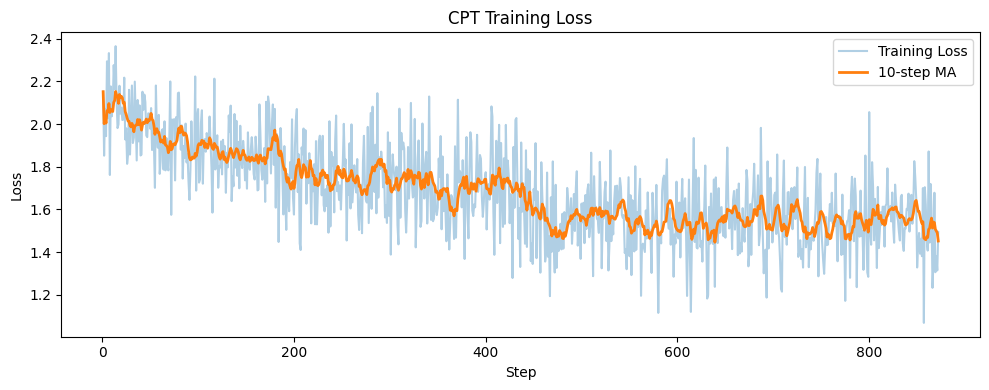

>> Loss plot saved: cpt_loss.png


In [23]:
# Stage 6E: Dynamic CPT loss summary

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

loss_values = [e["loss"] for e in trainer.state.log_history if "loss" in e]

half = len(loss_values) // 2

print("CPT Loss Summary")
print("-" * 20)
print(f"Logged steps           : {len(loss_values):,}")
print(f"First loss             : {loss_values[0]:.4f}")
print(f"Final loss             : {loss_values[-1]:.4f}")
print(f"Minimum loss           : {min(loss_values):.4f}")
print(f"Mean loss              : {np.mean(loss_values):.4f}")
print(f"First-half mean        : {np.mean(loss_values[:half]):.4f}")
print(f"Second-half mean       : {np.mean(loss_values[half:]):.4f}")

loss_df = pd.DataFrame({"step": loss_callback.steps, "loss": loss_callback.losses})
loss_df["ma"] = loss_df["loss"].rolling(window=10, min_periods=1).mean()

plt.figure(figsize=(10, 4))
plt.plot(loss_df["step"], loss_df["loss"], alpha=0.35, label="Training Loss")
plt.plot(loss_df["step"], loss_df["ma"], linewidth=2, label="10-step MA")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("CPT Training Loss")
plt.legend()
plt.tight_layout()
plt.savefig("cpt_loss.png", dpi=120)
plt.show()
print(">> Loss plot saved: cpt_loss.png")

### CPT Training and Loss Observation

Continued pretraining ran on an NVIDIA A100-SXM4-80GB for 2 epochs over the 1,747 training blocks. It completed all 872 optimizer steps (436 per epoch) in 9 minutes 43 seconds. That is about 3.58M training tokens at roughly 6,100 tokens per second.

| Measure | Value |
|---|---|
| Logged steps | 872 |
| First loss | 2.1519 |
| Final loss | 1.4950 |
| Minimum loss | 1.0687 (step 857) |
| Mean loss | 1.6804 |
| First-half mean | 1.8130 |
| Second-half mean | 1.5478 |

**Loss trend.** The mean loss of the second half (1.5478) is 0.265 lower than the first half (1.8130), a drop of about 15%. The single-step first, final and minimum values are noisy and should not be used on their own: each update uses only 4 blocks, so individual steps range from about 1.07 to 2.37. The averages over blocks of steps give a clearer view.

**Shape of the curve.** The mean loss falls in stages: 1.98 over steps 1 to 100, 1.84 over steps 101 to 200, 1.76 over steps 201 to 300 and 1.71 over steps 301 to 436. In the second epoch it drops to 1.56 over steps 437 to 480 and then stays almost flat: 1.56 over steps 481 to 600 and 1.54 over steps 601 to 872. The step down at the epoch boundary is typical when the model sees the same blocks for a second time. Part of that gain comes from having seen these exact blocks before, not from learning more general domain language.

**Reading the result.** A training loss of about 1.5 on the domain text shows the model has adapted to the finance corpus. The flat second epoch suggests that a third epoch would add little and would raise the risk of memorising the documents. Training loss alone cannot show how well the model generalises. The held-out perplexity in the next stage is the test on blocks the model never trained on.

### Stage 6F: Save the CPT Model

The model obtained after continued pretraining is saved together with its tokenizer.

Saving the CPT checkpoint preserves the finance-adapted model for subsequent evaluation and QLoRA fine-tuning without requiring the CPT training process to be repeated.

In [24]:
# Stage 6F: Save CPT model and tokenizer

CPT_MODEL_DIR = Path("cpt_model")

print("Stage 6F: Saving CPT Model")
print("-" * 28)

model.save_pretrained(CPT_MODEL_DIR)
tokenizer.save_pretrained(CPT_MODEL_DIR)

assert CPT_MODEL_DIR.exists()
assert (CPT_MODEL_DIR / "config.json").exists()

print(f"Saved to : {CPT_MODEL_DIR}/")
print("\n>> [OK] CPT model and tokenizer saved.")

Stage 6F: Saving CPT Model
----------------------------
Saved to : cpt_model/

>> [OK] CPT model and tokenizer saved.


## Step 5: CPT Evaluation

This step evaluates whether continued pretraining improved the model's adaptation to the finance domain.

The evaluation includes:

- Computing perplexity on the held-out finance-domain sequences that were excluded from CPT.
- Comparing the **base SmolLM2-360M model** against the **CPT-adapted model** on the same held-out data.
- Re-running the same ten finance-domain prompts used before CPT and comparing the generated responses.
- Testing general-purpose prompts before and after CPT to identify possible catastrophic forgetting.

A lower held-out perplexity after CPT indicates improved predictive fit to the finance-domain corpus.

#### Stage 7A: Held-Out Perplexity Evaluation

Perplexity measures how well a language model predicts unseen text. It is calculated as the exponential of the average negative log-likelihood.

Both the original pretrained model and the CPT-adapted model are evaluated on the same held-out finance-domain sequences to provide a direct comparison.

Lower perplexity indicates better predictive performance on the held-out finance-domain text.

In [25]:
# Stage 7A: Perplexity evaluation function

import math
import torch


def calculate_perplexity(model, dataset, device):
    model.eval()

    total_loss = 0.0
    total_tokens = 0

    with torch.no_grad():
        for sample in dataset:
            input_ids = sample["input_ids"].unsqueeze(0).to(device)
            labels = sample["labels"].unsqueeze(0).to(device)

            outputs = model(
                input_ids=input_ids,
                labels=labels
            )

            # Causal LM loss predicts tokens 1...N from tokens 0...N-1
            predicted_tokens = labels.numel() - 1

            total_loss += outputs.loss.item() * predicted_tokens
            total_tokens += predicted_tokens

    average_nll = total_loss / total_tokens
    perplexity = math.exp(average_nll)

    return average_nll, perplexity


print("Stage 7A: Held-Out Evaluation Setup")
print("-" * 38)
print(f"Held-out sequences : {len(cpt_holdout_dataset)}")
print(f"Sequence length    : {CPT_SEQUENCE_LENGTH:,}")
print(
    f"Evaluation tokens  : "
    f"{len(cpt_holdout_dataset) * (CPT_SEQUENCE_LENGTH - 1):,}"
)

print("\n>> [OK] Perplexity evaluation function ready.")

Stage 7A: Held-Out Evaluation Setup
--------------------------------------
Held-out sequences : 197
Sequence length    : 1,024
Evaluation tokens  : 201,531

>> [OK] Perplexity evaluation function ready.


### Held-Out Evaluation Setup Observation

| Measure | Value |
|---|---|
| Held-out sequences | 197 |
| Sequence length | 1,024 tokens |
| Evaluation tokens | 201,531 |

**Token count.** The 197 held-out blocks hold 201,728 tokens, but 201,531 are scored. The difference is 197 tokens, one per block. In next-token prediction the first token of a block has no earlier token to be predicted from, so each block provides 1,023 predictions (197 × 1,023 = 201,531).

**Method.** Perplexity is the exponential of the average next-token loss over these 201,531 tokens. A lower value means the model finds the held-out finance text less surprising. The same function, on the same held-out blocks, is applied to the base model and to the model after CPT, so the two values are directly comparable.

**Coverage.** The held-out text comes from the end of every document and was never used for training (Stage 6B), so it measures how well CPT generalises to unseen text from the same domain. A small share of held-out text (4.7% of 16-token windows) also appears in training because of repeated legal and report wording, so the perplexity is slightly optimistic. This applies equally to both models.

### Stage 7B: CPT Model Perplexity

The CPT model is evaluated on the held-out blocks that were never used in training. Perplexity is the exponential of the average negative log-likelihood per token, so a lower value means the model predicts unseen domain text better. The same function is used for the base model in Stage 7C so the two scores are directly comparable.

In [26]:
# Stage 7B: Evaluate CPT model perplexity

model.to(DEVICE)

cpt_nll, cpt_perplexity = calculate_perplexity(model, cpt_holdout_dataset, DEVICE)

print("Stage 7B: CPT Model Perplexity")
print("-" * 32)
print(f"Average NLL : {cpt_nll:.4f}")
print(f"Perplexity  : {cpt_perplexity:.4f}")
print("\n>> [OK] CPT model evaluation completed.")

Stage 7B: CPT Model Perplexity
--------------------------------
Average NLL : 1.7501
Perplexity  : 5.7551

>> [OK] CPT model evaluation completed.


### CPT Model Perplexity Observation

| Measure | Value |
|---|---|
| Held-out tokens scored | 201,531 |
| Average negative log-likelihood | 1.7501 |
| **Perplexity after CPT** | **5.7551** |

**Meaning.** Perplexity is the exponential of the average loss (e^1.7501 = 5.7551). On average, the CPT model is as uncertain about each held-out token as if it were choosing between about 5.8 equally likely tokens. This is the model's score on finance text that was never used for training.

**Link to the training loss.** The held-out loss (1.7501) is higher than the training loss in the second half of CPT (1.5479, a perplexity of about 4.7). A held-out loss above the training loss is expected, because the model has seen the training blocks twice and the held-out blocks never. The gap of about 0.2 in loss (1.7501 against 1.5478) is modest. It suggests the model learned general domain patterns and did not simply memorise the training blocks.

**Comparison.** This value is meaningful only against the base model's perplexity on the same held-out blocks. That comparison, and the check on general-domain forgetting, follow in the next stages.

### Stage 7C: Base Model Perplexity

The original pretrained SmolLM2-360M model is evaluated on the **same held-out finance-domain sequences** used for the CPT model.

Using identical evaluation data provides a direct comparison between the original base model and the finance-adapted CPT model. A lower perplexity for the CPT model would indicate improved predictive fit to the held-out finance-domain corpus.

In [27]:
# Stage 7C: Evaluate base model perplexity

import gc
from transformers import AutoModelForCausalLM

model.to("cpu")
gc.collect()
torch.cuda.empty_cache()

print("Stage 7C: Base Model Perplexity")
print("-" * 33)
print("Loading original pretrained model...\n")

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, torch_dtype=MODEL_DTYPE
).to(DEVICE)

base_nll, base_perplexity = calculate_perplexity(base_model, cpt_holdout_dataset, DEVICE)

ppl_change = base_perplexity - cpt_perplexity
ppl_pct = ppl_change / base_perplexity * 100

print("Perplexity Comparison")
print("-" * 30)
print(f"Base model PPL : {base_perplexity:.4f}")
print(f"CPT model PPL  : {cpt_perplexity:.4f}")
print(f"Improvement    : {ppl_change:+.4f} ({ppl_pct:+.1f}%)")

if cpt_perplexity < base_perplexity:
    print("\n>> CPT reduced perplexity, domain adaptation worked.")
else:
    print("\n>> CPT did not reduce perplexity on this held-out set.")
    print("   Consider more corpus tokens or additional epochs.")

base_model.to("cpu")
del base_model
gc.collect()
torch.cuda.empty_cache()
model.to(DEVICE)

print("\n>> [OK] Perplexity evaluation complete.")

Stage 7C: Base Model Perplexity
---------------------------------
Loading original pretrained model...

Perplexity Comparison
------------------------------
Base model PPL : 7.6670
CPT model PPL  : 5.7551
Improvement    : +1.9118 (+24.9%)

>> CPT reduced perplexity, domain adaptation worked.

>> [OK] Perplexity evaluation complete.


### Base Model Perplexity Observation

| Measure | Value |
|---|---|
| Held-out tokens scored | 201,531 |
| Base model perplexity | 7.6670 |
| Base model average loss | about 2.04 |

**Meaning.** Before any training, SmolLM2-360M is about as uncertain about each token of the held-out RBI and SEBI text as if it were choosing between 7.7 equally likely tokens. This is the reference point for judging CPT. It is measured on the same 197 held-out blocks that the CPT model is scored on later, so the comparison is fair.

**Consistency with the training run.** The average loss of about 2.04 matches the start of CPT training, where the first logged step was 2.1519 and the first 100 steps averaged 1.9796. This shows that the evaluation function and the training loss measure the same thing, and that training began from the same base model.

**A moderate starting point.** A perplexity of 7.7 is not high. The base model already reads English finance and legal prose reasonably well, because it was pretrained on a large general corpus. The weakness shown in the baseline answers (Stage 5D) is mostly missing Indian regulatory knowledge: terms such as security receipts, ARCs, UPI and SEBI buy-back rules. Perplexity captures this only partly, because many tokens in the held-out text are ordinary English that the base model predicts well. This is also why a 25% perplexity reduction from CPT is a meaningful gain.

### Perplexity Comparison Observation

| Model | Held-out perplexity | Average loss (log of perplexity) |
|---|---|---|
| Base SmolLM2-360M | 7.6670 | 2.0368 |
| After CPT | 5.7551 | 1.7501 |
| **Change** | **-1.9118 (24.9% lower)** | **-0.2867 (14.1% lower)** |

**Result.** Continued pretraining reduced perplexity on the held-out finance text from 7.6670 to 5.7551, a reduction of 24.9%. The model finds unseen RBI and SEBI text about a quarter less surprising than the original pretrained model did. Measured as average loss per token, the gain is 0.29 nats. Perplexity is the exponential of the loss, so a modest drop in loss shows up as a larger percentage change in perplexity.

**Why this is a fair comparison.** Both models were scored on the same 197 held-out blocks (201,531 tokens) that were never used for training, with the same evaluation function. The gain therefore comes from CPT and not from the choice of test text.

**Context.**
- A small share of held-out text (4.7% of 16-token windows) also appears in training through repeated legal and report wording. This makes both perplexities, and especially the CPT figure, slightly optimistic.

**Limit.** A lower perplexity shows that the model predicts domain text better. It does not by itself show that the model answers questions correctly. That depends on the instruction tuning (QLoRA) stage, and the next check is whether CPT harmed the model's general ability.

#### Stage 7D: Domain Prompt Comparison

The same ten finance-domain prompts used for baseline inference before CPT are now evaluated using the CPT-adapted model.

Using identical prompts and generation settings enables a direct qualitative comparison between the base model and the domain-adapted model.

In [28]:
# Stage 7D: Post-CPT domain prompts (same prompts and GENERATE_KWARGS as Stage 5D)

model.eval()
cpt_responses = []

print("Stage 7D: Post-CPT Domain Prompt Evaluation")
print("-" * 45)
print(f"Generation: {GENERATE_KWARGS}\n")

for i, prompt in enumerate(all_domain_prompts, 1):
    response = generate_text(model, tokenizer, prompt)
    cpt_responses.append(response)
    print(f"Prompt {i}\n{prompt}\n\nCPT Response:\n{response}\n" + "-" * 70)

Stage 7D: Post-CPT Domain Prompt Evaluation
---------------------------------------------
Generation: {'max_new_tokens': 150, 'do_sample': False, 'repetition_penalty': 1.1, 'no_repeat_ngram_size': 4}

Prompt 1
Explain the risks faced by individual traders in equity derivatives markets.

CPT Response:
(2) 
Describe the major trends and developments in the equity derivatives market, including their impact on retail participation.

Part B: Financial Markets (30 marks)

Question 1: 
(a) 
Briefly explain the role of financial intermediaries in facilitating capital flows to and from the financial system. 
(b) 
What are the key features of a sound financial system? 
(c) 
How does the banking sector contribute to the liquidity of the financial system? 

(4) 
(d) 
In your opinion, what is the role of banks in promoting financial stability? 
Explanation should be given for each part of this question.
----------------------------------------------------------------------
Prompt 2
Explain how UPI 

### Post-CPT Domain Prompt Observation

The same ten prompts and decoding settings as the baseline (Stage 5D) were used, so differences come from the model.

**What improved**
- **Domain register.** The model now writes in the style of RBI and SEBI documents: lettered and numbered clauses ("(a)", "(b)", "10.3.2"), "The Board shall…", chapter and regulation headings. The base model wrote generic web text, often with US references (SEC, Nasdaq, NYSE). Those US references no longer appear.
- **Domain vocabulary.** Terms such as the Reserve Bank, payments ecosystem, shareholding pattern, voting rights and stock exchange are used naturally.
- **Some better content.** Prompt 3 now defines a buy-back as an issuer buying back its own shares from shareholders, directly or through a stock exchange, and links it to earnings per share. This is closer to the real routes than the base model's answer. Prompt 5 gives the vision of a seamless, secure and efficient payments system in the RBI's own style, followed by a numbered list of objectives.

**What did not improve**
- **Questions are continued, not answered.** CPT trains the model to continue documents. For prompts 1, 2 and 4 it produced exam-paper text ("Part B: Financial Markets (30 marks)", "Write a short note on any one of the following", "Answer any FIVE questions from this section") instead of an answer. Prompt 2 lists topics and never explains how UPI helped. Prompt 7 turns into a book introduction ("In this chapter, we will explore…").
- **Factual errors remain.** Prompt 9 defines a security receipt wrongly ("a guarantee that the borrower will repay") and then drifts into a glossary on bankruptcy and debt management plans. Prompt 8 lists "an offer to subscribe for" and "a special resolution" as buy-back routes, then moves on to shareholding pattern and voting rights; the SEBI buy-back document describes a tender offer and open market purchases. Prompt 10 answers a LODR question with the contents of a public issue offer (price per share, subscription period, refund procedure), which belongs to a different regulation.
- **Invented content.** Prompt 6 does not state the SEBI study's finding. It says traders are concentrated in options and brings in "alternative investment strategies such as leveraged buyouts, private placements", which is not what the study is about.
- **PDF layout leaks into the text.** Prompt 3 splits "buy-back" across lines ("buy-" then a blank line) and prompt 8 breaks a sentence after "by way" onto the next line. The model has learned the layout of the source PDFs along with their content.
- **Length.** Eight of the ten outputs (prompts 3 to 10) stop mid-sentence at the 150-token limit. Only prompts 1 and 2 end at a complete sentence.

**Conclusion.** CPT moved the model's language towards the domain, which matches the 24.9% perplexity reduction. It did not teach the model to answer questions or to state facts reliably. Instruction tuning (QLoRA) on grounded question and answer pairs is needed for that, and its results should be compared against this table.

#### Stage 7E: Catastrophic Forgetting Check

Continued pretraining on a specialized domain can potentially reduce a model's performance on general-domain tasks, a phenomenon known as **catastrophic forgetting**.

To check for this effect, the original base model and the CPT-adapted model are evaluated using the same general-purpose prompts with identical generation settings.

The responses are compared qualitatively and classified as **Retained** or **Degraded** based on whether the CPT model preserves the general capability demonstrated by the base model.

In [29]:
# Stage 7E: Catastrophic forgetting (same GENERATE_KWARGS as every other stage)

general_prompts = [
    "Explain why the sky appears blue.",
    "What are the main benefits of regular physical exercise?",
    "Explain the difference between a renewable and non-renewable energy source.",
    "The capital of France is",
    "Water boils at",
]

model.to(DEVICE)
model.eval()
cpt_general_outputs = [generate_text(model, tokenizer, p) for p in general_prompts]

# Load a fresh base model for comparison
model.to("cpu")
gc.collect()
torch.cuda.empty_cache()

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, torch_dtype=MODEL_DTYPE
).to(DEVICE)
base_model.eval()
base_general_outputs = [generate_text(base_model, tokenizer, p) for p in general_prompts]

base_model.to("cpu")
del base_model
gc.collect()
torch.cuda.empty_cache()
model.to(DEVICE)

print("Stage 7E: Catastrophic Forgetting Comparison")
print("-" * 45)
for i, prompt in enumerate(general_prompts):
    print(f"\nPrompt {i+1}: {prompt}")
    print("\nBASE RESPONSE:")
    print(base_general_outputs[i])
    print("\nCPT RESPONSE:")
    print(cpt_general_outputs[i])
    print("-" * 70)

Stage 7E: Catastrophic Forgetting Comparison
---------------------------------------------

Prompt 1: Explain why the sky appears blue.

BASE RESPONSE:
The light from the sun is made up of all colors, or wavelengths, of visible light. When sunlight passes through Earth's atmosphere, it collides with molecules and particles in the air. These collisions scatter the shorter wavelength colors (blue) more than longer ones (red), green, yellow, etc., making the sky appear blue.

2. What are some other ways that we can see things?

We can also see things by looking at them directly, using a microscope to look at very small objects, or by observing changes in an object over time. For example, if you drop a pebble into a pond, ripples will spread out across the water surface. By watching these ripples develop, you can learn about how waves

CPT RESPONSE:
(b) The sun is a star, which is a very hot ball of gas. It gives out light and heat in all directions. This makes it appear as if the sky is f

### Catastrophic Forgetting Observation

Five general-knowledge prompts outside finance were given to both the base model and the CPT model with the same decoding settings. The test checks whether training on RBI and SEBI text damaged what the model knew before.

| Prompt | Base model | CPT model | Verdict | Note |
|---|---|---|---|---|
| 1. Why the sky appears blue | Correct explanation (shorter wavelengths scatter more) | No scattering explanation; says the sun is a ball of gas and the sky "is full of bright lights", then moves to how eyes see light | Degraded | No answer given |
| 2. Benefits of exercise | Bulleted list, then drifts into "10 tips" and a web-page fragment | Fluent paragraph on cardiovascular fitness, mental wellbeing and disease risk, then a guideline on weekly minutes | Retained | Correct, fluent |
| 3. Renewable vs non-renewable energy | Correct definitions and examples, then drifts into other questions | No definitions; a list of sources with Indian figures (solar 30% and 12 GW, wind 45% "in 2026", geothermal 17 GW, tidal 2.9 GW "since 2012") that look invented | Degraded | Answer lost, fabricated figures |
| 4. The capital of France is | "Paris", then wrong details (20 million people, 13 districts, a light bulb in 1875) | "the Bank of France (BFA)", then RBI monetary policy text (the MPC, "pegged to the US dollar") | Degraded | Wrong answer, domain text takes over |
| 5. Water boils at | "100 degrees Celsius", then contradicts itself ("105 degrees Celsius") | "100 degrees centigrade", then drifts to kettles and steam gauges | Retained | Correct start, then drifts |

**Results.** Two of the five prompts (2 and 5) are Retained and three (1, 3 and 4) are Degraded. In the other three the CPT model fails to give the correct answer: it gives none on prompt 1, invents statistics on prompt 3, and answers prompt 4 with the wrong entity and then writes RBI monetary-policy text. The base model gave a correct core answer on all five, with errors in its extra detail on prompts 4 and 5.

**What this shows.**
- **Domain bleed.** On prompts 3 and 4 the model answers general questions with Indian regulatory content and report-style wording. The fabricated statistics on prompt 3 are the clearest harm in this test.
- **Document-style continuation.** The model continues text and does not treat the question as a request, which is the same pattern as on the finance questions.
- **Fluency is intact.** Every output is grammatical English, so the model has not collapsed. The loss is in what it answers, not in how it writes.

**Conclusion.** Forgetting is real here. It is not total, since two prompts are still answered correctly, but three of five general questions no longer get a correct answer after CPT. An earlier run of the same notebook returned "Paris" for prompt 4, so single-prompt results at this scale are fragile and vary between runs. The QLoRA stage did not repeat this test, so the final model's general knowledge is not measured.

**Limit.** Five prompts give a qualitative view only. A general-text perplexity check before and after CPT would give a number for the same question.

## Step 6: Instruction Dataset Preparation

The cleaned finance-domain corpus produced in Step 1 is now transformed into an instruction-response dataset for supervised QLoRA fine-tuning.

Each example contains:

- `instruction` — a question or task derived from the finance-domain text.
- `response` — an answer grounded directly in the corresponding corpus content.

The resulting examples are saved in **JSONL format** and divided into an **80/20 training and evaluation split** for subsequent QLoRA fine-tuning.

#### Stage 8A: Load Cleaned Finance Corpus

The 30 cleaned `.txt` documents from the CPT corpus are loaded as the source material for instruction-dataset construction.

Only the cleaned corpus is used so that the instruction-response examples remain grounded in the same finance domain used during continued pretraining.

In [30]:
# Stage 8A: Load cleaned corpus for instruction generation

cleaned_files = sorted(FINAL_CORPUS_DIR.glob("*.txt"))

instruction_source_documents = []

for file_path in cleaned_files:
    text = file_path.read_text(encoding="utf-8").strip()

    instruction_source_documents.append({
        "document": file_path.name,
        "text": text
    })

print("Stage 8A: Instruction Dataset Source")
print("-------------------------------------")
print(f"Source documents : {len(instruction_source_documents)}")

for i, document in enumerate(instruction_source_documents, 1):
    print(
        f"{i:02d}. {document['document']} "
        f"({len(document['text']):,} characters)"
    )

assert len(instruction_source_documents) == expected_pdf_count

print("\n>> [OK] Cleaned finance corpus loaded.")

Stage 8A: Instruction Dataset Source
-------------------------------------
Source documents : 30
01. Profitability of Individual Traders in the Equity Derivatives Segment (FY25–FY26).txt (138,593 characters)
02. RBI - Annual Report 2023-24.txt (805,274 characters)
03. RBI - Annual Report 2025-26.txt (612,611 characters)
04. RBI - Asset Reconstruction Companies Directions 2025.txt (130,075 characters)
05. RBI - Asset Reconstruction Companies – Credit Information Reporting Directions 2025.txt (74,228 characters)
06. RBI - Asset Reconstruction Companies – Know Your Customer Directions 2025.txt (163,517 characters)
07. RBI - Asset Reconstruction Companies – Treatment of Wilful Defaulters and Large Defaulters Directions 2025.txt (17,248 characters)
08. RBI - Benchmarking Indias Payments Systems - 2022.txt (138,602 characters)
09. RBI - Digital Lending Guidelines.txt (20,132 characters)
10. RBI - Digitalisation and Payment Revolution in India 2024.txt (102,973 characters)
11. RBI - Financial

### Instruction Dataset Source Observation

| Measure | Value |
|---|---|
| Source documents loaded | 30 |
| Total characters | 7,160,100 |
| Shortest document | 17,248 characters (ARC Wilful and Large Defaulters Directions 2025) |
| Longest document | 1,071,663 characters (SEBI ICDR Regulations, March 2026) |

**Same text as CPT.** The 30 cleaned documents loaded here are the same files that CPT used, and their total of 7,160,100 characters matches the cleaned total from Stage 3A. The instruction data is therefore written against the same text the model was pretrained on, and the grounding check (does the evidence span appear in the source) uses exactly this text.

**Mix of sources.** The corpus covers RBI reports and directions, RBI payment-system publications, and SEBI regulations and circulars, plus two SEBI studies on individual derivatives traders. This gives the instruction pairs a wide range of topics, from payments (UPI, prepaid instruments, payment aggregators) to asset reconstruction, listing rules, mutual funds and takeovers.

**Coverage check.** Stage 8B shows that all 30 of these documents have instruction pairs, so QLoRA sees question and answer examples written about every document that CPT saw.

#### Stage 8B: Load the Curated Grounded Instruction-Response Pairs

Automatic paragraph-to-question conversion was avoided because the extracted PDF corpus contains tables, page headers, contents pages, acknowledgements, and other material that does not form meaningful instruction-response examples.

Instead, each source document was read and question-answer pairs were written from its substantive provisions, findings and figures. The pairs cover all 30 documents and are stored in the repository at `data/instruction/instruction_dataset_curated.jsonl`.

Every pair carries three traceability fields besides the two training fields:

- `source_document` — the corpus document the pair was written from.
- `evidence` — one verbatim sentence or phrase from that document that supports the key fact in the response.

Each `evidence` span was checked against the extracted PDF text when the dataset was built. This stage loads the file, checks that every source document exists in the cleaned corpus, and reports how many evidence spans can be found in the cleaned text. The instructions name their source document, so they are self-contained when used for training.

In [31]:
# Stage 8B: Load the curated, source-checked instruction dataset

import json
import re
import pandas as pd

CURATED_PATH = REPO_DIR / "data" / "instruction" / "instruction_dataset_curated.jsonl"
assert CURATED_PATH.exists(), f"Curated dataset not found: {CURATED_PATH}"

with open(CURATED_PATH, encoding="utf-8") as f:
    instruction_examples = [json.loads(line) for line in f if line.strip()]

instruction_df = pd.DataFrame(instruction_examples)

required_columns = {"instruction", "response", "source_document", "evidence"}
assert required_columns <= set(instruction_df.columns), "Curated file is missing a required field."

# Every pair must trace back to a document in the cleaned corpus
normalise = lambda s: re.sub(r"\s+", " ", s).strip()
cleaned_text = {d["document"]: normalise(d["text"]) for d in instruction_source_documents}

known_source = instruction_df["source_document"].isin(cleaned_text)
unknown_sources = sorted(instruction_df.loc[~known_source, "source_document"].unique())

evidence_found = [
    normalise(row.evidence) in cleaned_text.get(row.source_document, "")
    for row in instruction_df.itertuples()
]

print("Stage 8B: Curated Instruction Dataset")
print("--------------------------------------")
print(f"Total examples            : {len(instruction_df)}")
print(f"Unique instructions       : {instruction_df['instruction'].nunique()}")
print(f"Source documents used     : {instruction_df['source_document'].nunique()} of {len(cleaned_text)}")
print(f"Pairs with known source   : {int(known_source.sum())} / {len(instruction_df)}")
print(f"Evidence found in cleaned text: {sum(evidence_found)} / {len(instruction_df)} "
      f"({sum(evidence_found) / len(instruction_df):.1%})")

if unknown_sources:
    print("\nWARNING - source names not in the cleaned corpus:")
    for name in unknown_sources:
        print("  -", name)

no_pairs = sorted(set(cleaned_text) - set(instruction_df["source_document"]))
print(f"\nCorpus documents without instruction pairs: {len(no_pairs)}")
for name in no_pairs:
    print("  -", name)

print("\nExamples per source:")
print(instruction_df["source_document"].value_counts())

print("\nSample pair:")
print("Instruction:")
print(instruction_df.iloc[0]["instruction"])
print("\nResponse:")
print(instruction_df.iloc[0]["response"])

assert known_source.mean() >= 0.9, "More than 10% of pairs have a source document that is not in the cleaned corpus."

print("\n>> [OK] Curated grounded instruction dataset loaded.")


Stage 8B: Curated Instruction Dataset
--------------------------------------
Total examples            : 1196
Unique instructions       : 1196
Source documents used     : 30 of 30
Pairs with known source   : 1196 / 1196
Evidence found in cleaned text: 1181 / 1196 (98.7%)

Corpus documents without instruction pairs: 0

Examples per source:
source_document
RBI - Annual Report 2025-26.txt                                                                                                                          135
SEBI - Compliance with the provisions of the Securities and Exchange Board of India (Listing Obligations and Disclosure Requirements Regulations,.txt    112
SEBI Infrastructure Investment Trusts.txt                                                                                                                 86
SEBI - IDCR Regulations March 2026.txt                                                                                                                    60
SEBI Issue and 

### Curated Instruction Dataset Observation

| Measure | Value |
|---|---|
| Total examples | 1,196 |
| Unique instructions | 1,196 (no duplicates) |
| Source documents used | 30 of 30 |
| Pairs with a known source document | 1,196 / 1,196 |
| Pairs whose evidence is found in the cleaned text | 1,181 / 1,196 (98.7%) |
| Corpus documents without instruction pairs | 0 |

**Grounding.** Every pair names its source document, and 98.7% have their evidence span found verbatim in the cleaned text, so nearly all answers can be traced to the corpus. The 15 pairs whose evidence was not found (1.3%) probably differ from the source in spacing or line-break wording. They are a small share and do not affect the check that at least 90% of pairs are grounded.

**Full coverage.** All 30 documents have pairs, so QLoRA sees question and answer examples about every document that CPT saw. The number of pairs per document ranges from 15 (the SEBI Investor Protection and Education Fund, and the ARC Wilful and Large Defaulters Directions) to 135 (the RBI Annual Report 2025-26).

**Uneven coverage by document.** The pairs are still concentrated in the larger sources. The RBI Annual Report 2025-26 (135), the SEBI LODR document (112), the SEBI Infrastructure Investment Trusts regulations (86) and the SEBI ICDR Regulations (60) together hold 393 pairs, about 33% of the dataset. The two longest documents, the ICDR Regulations (276,020 tokens) and the RBI Annual Report 2023-24 (249,555 tokens), have 60 and 50 pairs, so long documents get fewer pairs per token than short ones.

**Effect on evaluation.** The domain prompts used for the baseline, post-CPT and post-QLoRA checks (UPI, buy-backs, ARCs, Payments Vision 2025, the SEBI trader studies, LODR) all come from documents that have pairs, so QLoRA has a fair chance on them. Because every document now has pairs, this dataset cannot separate what CPT contributed from what instruction tuning taught for any single document.

**Size.** 1,196 examples is small for instruction tuning, but it suits QLoRA with a small model. The sample pair is short, specific and answered in one sentence, which matches the style the later evaluation expects.

#### Stage 8C: Validate Instruction-Response Pairs

The curated dataset is checked before saving.

Validation ensures that:
- Every example contains a non-empty instruction.
- Every example contains a non-empty response.
- Instructions are unique.
- Exact duplicate instruction-response pairs are absent.
- Administrative PDF text such as acknowledgements is not present in the training responses.

The source-document field is retained during validation for traceability but is not required in the final JSONL file.

In [32]:
# Stage 8C: Validate instruction dataset

assert len(instruction_df) > 0

assert instruction_df["instruction"].notna().all()
assert instruction_df["response"].notna().all()

assert (
    instruction_df["instruction"]
    .str.strip()
    .ne("")
    .all()
)

assert (
    instruction_df["response"]
    .str.strip()
    .ne("")
    .all()
)

duplicate_pairs = instruction_df.duplicated(
    subset=["instruction", "response"]
).sum()

admin_terms = [
    "gratefully acknowledge",
    "special thanks are due",
    "table of contents"
]

admin_matches = 0

for response in instruction_df["response"]:
    lower = response.lower()

    if any(term in lower for term in admin_terms):
        admin_matches += 1


print("Stage 8C: Dataset Validation")
print("-----------------------------")
print(f"Examples              : {len(instruction_df)}")
print(f"Duplicate pairs       : {duplicate_pairs}")
print(f"Administrative matches: {admin_matches}")

assert duplicate_pairs == 0
assert admin_matches == 0

print("\n>> [OK] Instruction dataset validation passed.")

Stage 8C: Dataset Validation
-----------------------------
Examples              : 1196
Duplicate pairs       : 0
Administrative matches: 0

>> [OK] Instruction dataset validation passed.


### Dataset Validation Observation

| Check | Result |
|---|---|
| Examples | 1,196 |
| Duplicate pairs | 0 |
| Administrative matches | 0 |

**No duplicates.** Each of the 1,196 instruction and response pairs is unique, so no question is repeated and no pair is weighted more heavily in QLoRA than the others. This agrees with Stage 8B, where all 1,196 instructions were unique.

**No administrative content.** None of the pairs matched the administrative-content check, which looks for questions and answers about document housekeeping (for example circular numbers, dates and addressee lines) instead of the subject matter. The training answers are therefore about regulation and policy content.

**Result.** The dataset passed validation unchanged, so all 1,196 examples are kept. They are exported in Stage 8D and split in Stage 8E.

#### Stage 8D: Save Instruction Dataset as JSONL

The validated examples are saved in the required JSONL format.

Only the two assignment-required fields are written to the final dataset:

- `instruction`
- `response`

Source-document metadata was used during construction and validation but is excluded from the submitted JSONL file.

In [33]:
# Stage 8D: Save final instruction dataset

import json
from pathlib import Path

INSTRUCTION_DATASET_PATH = Path("instruction_dataset.jsonl")

final_instruction_df = instruction_df[
    ["instruction", "response"]
].copy()

with open(
    INSTRUCTION_DATASET_PATH,
    "w",
    encoding="utf-8"
) as f:

    for record in final_instruction_df.to_dict(
        orient="records"
    ):
        f.write(
            json.dumps(
                record,
                ensure_ascii=False
            ) + "\n"
        )


print("Stage 8D: JSONL Export")
print("----------------------")
print(f"Output file : {INSTRUCTION_DATASET_PATH}")
print(f"Examples    : {len(final_instruction_df)}")

print("\nFirst JSONL record:")
print(
    json.dumps(
        final_instruction_df.iloc[0].to_dict(),
        indent=2,
        ensure_ascii=False
    )
)

print("\n>> [OK] instruction_dataset.jsonl saved.")

Stage 8D: JSONL Export
----------------------
Output file : instruction_dataset.jsonl
Examples    : 1196

First JSONL record:
{
  "instruction": "Under SEBI's Infrastructure Investment Trusts Regulations, what vote is needed to change the investment manager or its management fees?",
  "response": "Approval requires votes in favour of at least sixty per cent of total votes cast for the resolution."
}

>> [OK] instruction_dataset.jsonl saved.


### JSONL Export Observation

| Measure | Value |
|---|---|
| Output file | `instruction_dataset.jsonl` |
| Examples written | 1,196 |
| Fields per record | `instruction`, `response` |

**Format.** Each line of the file is one JSON record with only an `instruction` and a `response`. The source document and evidence fields used for grounding checks in Stage 8B are not exported. This is the format the submission asks for, and it is the format the QLoRA stage reads.

**Consistency.** The 1,196 exported records match the 1,196 examples that passed validation (Stage 8C), so nothing was lost or added during export. The first record is the same Infrastructure Investment Trusts question shown in Stage 8B, which confirms the file starts from the curated data.

**Style of the data.** Each question names its source regulation, and each response is a short, direct statement taken from the text (here, the vote needed to change the investment manager or its fees). This trains the model to answer concisely, which matches the way the evaluation questions are written.

#### Stage 8E: Create 80/20 Training and Evaluation Split

The instruction dataset is randomly shuffled using a fixed seed and divided into:

- **80% training examples**
- **20% evaluation examples**

A fixed random seed makes the split reproducible.

The evaluation examples are excluded from QLoRA training and retained for subsequent evaluation.

In [34]:
# Stage 8E: Reproducible 80/20 split

import random

records = final_instruction_df.to_dict(
    orient="records"
)

random.Random(42).shuffle(records)

split_index = round(
    len(records) * 0.80
)

train_records = records[:split_index]
eval_records = records[split_index:]

TRAIN_JSONL_PATH = Path(
    "instruction_dataset_train.jsonl"
)

EVAL_JSONL_PATH = Path(
    "instruction_dataset_eval.jsonl"
)


def save_jsonl(records, path):

    with open(path, "w", encoding="utf-8") as f:

        for record in records:
            f.write(
                json.dumps(
                    record,
                    ensure_ascii=False
                ) + "\n"
            )


save_jsonl(
    train_records,
    TRAIN_JSONL_PATH
)

save_jsonl(
    eval_records,
    EVAL_JSONL_PATH
)


print("Stage 8E: Instruction Dataset Split")
print("------------------------------------")
print(f"Total examples : {len(records)}")
print(f"Training       : {len(train_records)}")
print(f"Evaluation     : {len(eval_records)}")

print(
    f"\nTraining ratio : "
    f"{len(train_records) / len(records):.1%}"
)

print(
    f"Evaluation ratio: "
    f"{len(eval_records) / len(records):.1%}"
)

assert (
    len(train_records) +
    len(eval_records)
    == len(records)
)

print("\n>> [OK] 80/20 instruction split created.")

Stage 8E: Instruction Dataset Split
------------------------------------
Total examples : 1196
Training       : 957
Evaluation     : 239

Training ratio : 80.0%
Evaluation ratio: 20.0%

>> [OK] 80/20 instruction split created.


### Instruction Dataset Split Observation

| Set | Examples | Share |
|---|---|---|
| Training | 957 | 80.0% |
| Evaluation | 239 | 20.0% |
| Total | 1,196 | 100% |

**Split.** The 1,196 pairs were divided 80/20 into 957 training examples and 239 evaluation examples. The two sets together equal the full dataset, so no pair is dropped or counted twice. QLoRA trains only on the 957 pairs. The 239 evaluation pairs are kept aside for the loss and perplexity checks after training.

**What the evaluation set measures.** The split is made at the level of individual pairs, so the evaluation questions come from documents that also supply training pairs. The evaluation therefore measures whether the model answers new questions about documents it has seen question-and-answer examples for. It does not measure how well the model handles a document it has seen no pairs for.

**Size.** 239 evaluation examples is enough to compare the models, but small enough that a change of a few percent in the evaluation loss is within noise. Treat small differences between the post-CPT and post-QLoRA results with care.

## Step 7: QLoRA Instruction Fine-Tuning

The CPT checkpoint is now instruction fine-tuned using Quantized Low-Rank Adaptation (QLoRA).

The assignment's **Balanced Adapter configuration** is used:

#### QLoRA Settings

| Setting | Value | What it does |
|---|---|---|
| LoRA rank (`r`) | 16 | The base weights stay frozen. Each adapted weight matrix gets a small update built from two thin matrices, and the rank is the width of that bottleneck. A higher rank can capture more new behaviour but adds trainable parameters. 16 is a common middle setting: enough capacity to learn the question-answer style from 957 examples, with only a tiny fraction of the model trainable. |
| LoRA alpha | 32 | A scale applied to the adapter update. The update is multiplied by alpha divided by rank (32 / 16 = 2), so the adapter has a moderate influence on the output. Keeping alpha at twice the rank is a widely used default. |
| Target modules | `q_proj`, `v_proj` | The adapters are attached only to the query and value projections of each attention layer. Training only these keeps the number of trainable parameters very small and lowers the risk of overwriting the knowledge gained in CPT, while still letting the model change what it attends to and what it passes on. |
| 4-bit quantization | 4-bit NF4 | The frozen base model is loaded in 4-bit precision (NF4, with float16 compute). This cuts the weight memory to roughly a quarter of the float32 size, which is what makes the method "Q"LoRA. The adapters themselves train in higher precision. The cost is a small loss in accuracy: in this run, loading the CPT model in 4-bit raised held-out perplexity from 5.7551 to 6.2872 (9.2%). |

**Result.** Only the small adapter matrices are updated during QLoRA. The CPT model's weights are unchanged, and the adapters teach it to answer questions in the style of the 957 training pairs.

#### Stage 9A: Prepare QLoRA Libraries

The QLoRA stage requires `peft`, `bitsandbytes`, `trl`, and `datasets`.

Only missing packages are installed so that existing environment versions are left unchanged wherever possible.

In [35]:
# Stage 9A: Check/install QLoRA dependencies

import importlib.util
import subprocess
import sys

required_packages = {
    "peft": "peft",
    "bitsandbytes": "bitsandbytes",
    "trl": "trl",
    "datasets": "datasets"
}

print("Stage 9A: Check/install QLoRA dependencies")
print("-" * 42 + "\n")

for module_name, package_name in required_packages.items():

    if importlib.util.find_spec(module_name) is None:
        print(f">> Installing missing package: {package_name}")

        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            package_name
        ])

    else:
        print(f">> [OK] {package_name}")


print("\n>> [OK] QLoRA dependencies ready.")

Stage 9A: Check/install QLoRA dependencies
------------------------------------------

>> [OK] peft
>> [OK] bitsandbytes
>> [OK] trl
>> [OK] datasets

>> [OK] QLoRA dependencies ready.


#### QLoRA Dependency Observation

The packages needed for QLoRA (`peft`, `bitsandbytes`, `trl`, `datasets`) are installed and importable in the course environment, so Part B can run without further setup.

#### Stage 9B: Release GPU Memory

The full-precision models used during CPT evaluation are removed from memory before loading the 4-bit QLoRA model.

This avoids unnecessary GPU-memory usage on the GPU.

In [36]:
# Stage 9B: Release previous model objects

import gc
import torch

for variable_name in [
    "model",
    "base_model",
    "cpt_eval_model"
]:
    if variable_name in globals():
        del globals()[variable_name]

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("Stage 9B: Release previous model objects")
print("----------------------------------------")
print("GPU cache cleared.")

if torch.cuda.is_available():
    free_bytes, total_bytes = torch.cuda.mem_get_info()

    print(
        f"Free GPU memory : "
        f"{free_bytes / 1024**3:.2f} GiB"
    )

    print(
        f"Total GPU memory: "
        f"{total_bytes / 1024**3:.2f} GiB"
    )

print("\n>> [OK] GPU prepared for QLoRA.")

Stage 9B: Release previous model objects
----------------------------------------
GPU cache cleared.
Free GPU memory : 64.58 GiB
Total GPU memory: 79.15 GiB

>> [OK] GPU prepared for QLoRA.


### GPU Preparation Observation

The earlier CPT and evaluation model objects were released and the GPU cache was cleared before QLoRA training. 64.58 GiB of the 79.15 GiB total is free, so about 14.6 GiB is still in use. That memory is held by the CUDA context and by objects that are still referenced in the notebook session. The 4-bit model and LoRA adapters need only a few gigabytes, so the GPU has enough room for QLoRA.

#### Stage 9C: Load CPT Model in 4-bit Precision

The CPT checkpoint from Part A is loaded using 4-bit NF4 quantization through `bitsandbytes`.

FP16 is used as the compute dtype for the 4-bit layers. The tokenizer saved with the CPT checkpoint is reused to preserve vocabulary alignment.

In [37]:
# Stage 9C: Load CPT model for QLoRA

from pathlib import Path

import torch
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig
)

CPT_MODEL_DIR = Path("cpt_model")

assert CPT_MODEL_DIR.exists(), "CPT checkpoint not found."

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16
)

qlora_tokenizer = AutoTokenizer.from_pretrained(
    CPT_MODEL_DIR
)

qlora_model = AutoModelForCausalLM.from_pretrained(
    CPT_MODEL_DIR,
    quantization_config=bnb_config,
    device_map={"": 0},
    torch_dtype=torch.float16
)

# Use a pad token that is NOT the end-of-text token. If pad == EOS, the
# collator can mask the EOS label, and the model never learns to stop.
PAD_CANDIDATES = ["<empty_output>", "<jupyter_output>", "<jupyter_script>", "<file_sep>"]
vocab = qlora_tokenizer.get_vocab()

if qlora_tokenizer.pad_token is None or qlora_tokenizer.pad_token_id == qlora_tokenizer.eos_token_id:
    pad_choice = next(t for t in PAD_CANDIDATES if t in vocab)
    qlora_tokenizer.pad_token = pad_choice

assert qlora_tokenizer.pad_token_id != qlora_tokenizer.eos_token_id

qlora_model.config.pad_token_id = qlora_tokenizer.pad_token_id
qlora_model.config.use_cache = False

print("Stage 9C: 4-bit CPT Model")
print("-------------------------")
print(f"Model class       : {qlora_model.__class__.__name__}")
print(f"Tokenizer vocab   : {len(qlora_tokenizer):,}")
print(f"4-bit model       : {getattr(qlora_model, 'is_loaded_in_4bit', False)}")
print(f"Padding token     : {qlora_tokenizer.pad_token}")
print(f"Padding token ID  : {qlora_tokenizer.pad_token_id}")
print(f"EOS token / ID    : {qlora_tokenizer.eos_token} / {qlora_tokenizer.eos_token_id}")

print("\n>> [OK] CPT checkpoint loaded in 4-bit precision.")

Stage 9C: 4-bit CPT Model
-------------------------
Model class       : LlamaForCausalLM
Tokenizer vocab   : 49,152
4-bit model       : True
Padding token     : <empty_output>
Padding token ID  : 16
EOS token / ID    : <|endoftext|> / 0

>> [OK] CPT checkpoint loaded in 4-bit precision.


### 4-bit CPT Model Observation

| Measure | Value |
|---|---|
| Model class | `LlamaForCausalLM` |
| Tokenizer vocabulary | 49,152 |
| Loaded in 4-bit | Yes |
| Padding token | `<empty_output>` (id 16) |
| End-of-sequence token | `<|endoftext|>` (id 0) |

**Checkpoint.** The CPT model saved after Stage 6 was reloaded in 4-bit precision as the frozen base for QLoRA. This means the adapters are trained on top of the domain-adapted model, not the original SmolLM2. The model class is `LlamaForCausalLM` because SmolLM2 uses the Llama architecture. The vocabulary size of 49,152 matches the model's output layer from Stage 5C.

**Separate padding and end tokens.** The padding token is `<empty_output>` (id 16) and is different from the end-of-sequence token `<|endoftext|>` (id 0). By default these two would share one token. Padding positions are ignored in the loss, so a shared token would stop the model from ever learning to produce the end token, and answers would run on without stopping. With a separate padding token, the end token stays a real training label, so the model can learn to finish an answer.

**Memory.** The 4-bit load reduces the weight memory to about a quarter of the float32 size. Stage 10B shows that this adds some perplexity: 5.7551 for the CPT model in original precision against 6.2872 in 4-bit (9.2% higher).

#### Stage 9D: Configure Instruction Chat Template

QLoRA examples are formatted as user-assistant conversations before supervised fine-tuning.

If the tokenizer already provides a chat template it is reused. Otherwise, a simple user/assistant template is assigned so that all training examples follow a consistent instruction format.

In [38]:
# Stage 9D: Ensure a chat template is available

if not qlora_tokenizer.chat_template:

    qlora_tokenizer.chat_template = """
{% for message in messages %}
{% if message['role'] == 'user' %}
User: {{ message['content'] }}
{% elif message['role'] == 'assistant' %}
Assistant: {{ message['content'] }}{{ eos_token }}
{% endif %}
{% endfor %}
{% if add_generation_prompt %}
Assistant:
{% endif %}
"""

    template_source = "Notebook-defined user/assistant template"

else:
    template_source = "Tokenizer-provided template"


sample_messages = [
    {
        "role": "user",
        "content": train_records[0]["instruction"]
    },
    {
        "role": "assistant",
        "content": train_records[0]["response"]
    }
]

sample_formatted = qlora_tokenizer.apply_chat_template(
    sample_messages,
    tokenize=False,
    add_generation_prompt=False
)

print("Stage 9D: Chat Template")
print("-----------------------")
print(f"Template source: {template_source}")

print("\nFormatted training example:")
print(sample_formatted[:1000])

print("\n>> [OK] Chat formatting ready.")

Stage 9D: Chat Template
-----------------------
Template source: Notebook-defined user/assistant template

Formatted training example:

User: Under the RBI (Asset Reconstruction Companies) Directions, 2025, how is the NAV of an SR computed from the recovery rating?
Assistant: The ARC picks a percentage within the recovery range associated with the assigned rating and multiplies it by the face value of the SR to get the NAV, and it must give the rationale for the percentage chosen.<|endoftext|>


>> [OK] Chat formatting ready.


### Chat Template Observation

**Template.** Each training pair is converted into one plain-text example with a template defined in the notebook:

```
User: <instruction>
Assistant: <response><|endoftext|>
```

**End token.** The response ends with `<|endoftext|>` (id 0). Because this token is a normal training label (the padding token is a separate one, see Stage 9C), the model learns to stop after finishing an answer. Without it, the answers after QLoRA would run on, as the base and CPT answers did in the earlier prompt tests.

**Simple, consistent format.** The assignment asks for training text formatted with the model's chat template. SmolLM2-360M is a base model and its tokenizer has no chat template, so this notebook defines one explicitly: a plain "User:" and "Assistant:" format. This is a deliberate substitution, and Stage 9D reuses the tokenizer's own template whenever one exists. The same format must be used at test time: the prompt ends with "Assistant:" and the model completes the answer. Using a different prompt format at inference would reduce the benefit of the tuning.

**Content.** The example shown is a typical pair: a question that names the source regulation (the RBI Asset Reconstruction Companies Directions, 2025: how the NAV of a security receipt is computed from its recovery rating), followed by a one-sentence factual answer. Only the question and the answer enter the text; the source document and the evidence span are not part of the training example.

#### Stage 9E: Format Training and Evaluation Data

The 80/20 instruction split is converted into Hugging Face datasets.

Each `instruction` and `response` pair is formatted using the same chat template that will later be used during inference.

In [39]:
# Stage 9E: Build formatted SFT datasets

from datasets import Dataset

def format_record(record):

    messages = [
        {
            "role": "user",
            "content": record["instruction"]
        },
        {
            "role": "assistant",
            "content": record["response"]
        }
    ]

    return {
        "text": qlora_tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=False
        )
    }


train_sft_records = [
    format_record(record)
    for record in train_records
]

eval_sft_records = [
    format_record(record)
    for record in eval_records
]

train_dataset_sft = Dataset.from_list(
    train_sft_records
)

eval_dataset_sft = Dataset.from_list(
    eval_sft_records
)

print("Stage 9E: SFT Dataset")
print("----------------------")
print(f"Training examples  : {len(train_dataset_sft)}")
print(f"Evaluation examples: {len(eval_dataset_sft)}")

print("\nFormatted example:")
print(train_dataset_sft[0]["text"][:1000])

print("\n>> [OK] SFT datasets prepared.")

Stage 9E: SFT Dataset
----------------------
Training examples  : 957
Evaluation examples: 239

Formatted example:

User: Under the RBI (Asset Reconstruction Companies) Directions, 2025, how is the NAV of an SR computed from the recovery rating?
Assistant: The ARC picks a percentage within the recovery range associated with the assigned rating and multiplies it by the face value of the SR to get the NAV, and it must give the rationale for the percentage chosen.<|endoftext|>


>> [OK] SFT datasets prepared.


### SFT Dataset Observation

| Set | Examples |
|---|---|
| Training | 957 |
| Evaluation | 239 |

**Counts.** The training and evaluation counts match the 80/20 split from Stage 8E (957 + 239 = 1,196), so every pair was converted to the chat format and none were lost.

**Format.** Each example is a single text string in the "User / Assistant" template from Stage 9D, ending with `<|endoftext|>`. The SFT trainer reads this text, tokenizes it and trains the model to predict each token, so the model learns both the answer wording and where to stop.

**Ready for training.** The two datasets are the inputs to the QLoRA trainer in the next stage. The evaluation set is used only to measure loss during and after training, and it is not trained on.

#### Stage 9F: Configure Balanced LoRA Adapter

LoRA keeps the original weights fixed and adds a small set of extra weights, called an adapter, to part of the model. Only the adapter is trained on the 957 question-and-answer examples, which is fast and needs little memory.

- **Rank 16:** the size of the adapter. A larger rank gives it more room to learn but adds more trainable weights. 16 keeps it small.
- **Alpha 32:** how strongly the adapter's changes are applied to the model's output. With rank 16, the adapter's effect is scaled by 2 (32 / 16).
- **Target modules `q_proj`, `v_proj`:** the adapter is added only to the query and value projections of the attention layers, which decide what the model attends to and what information it passes on.
- **Dropout 0.05:** during training, 5% of the adapter's values are randomly switched off at each step. This reduces the chance that the adapter memorises the 957 examples instead of learning the pattern.

The 4-bit base model stays frozen, so the knowledge gained in CPT is not changed. The adapter only adds the habit of answering questions in the short, direct style of the training data.

In [40]:
# Stage 9F: Prepare QLoRA adapter

from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training
)

qlora_model = prepare_model_for_kbit_training(
    qlora_model
)

qlora_model.gradient_checkpointing_enable()

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=[
        "q_proj",
        "v_proj"
    ],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

qlora_model = get_peft_model(
    qlora_model,
    lora_config
)

print("Stage 9F: Balanced QLoRA Adapter")
print("--------------------------------")
qlora_model.print_trainable_parameters()

print("\nTarget modules : q_proj, v_proj")
print("LoRA rank      : 16")
print("LoRA alpha     : 32")

print("\n>> [OK] Balanced LoRA adapter attached.")

Stage 9F: Balanced QLoRA Adapter
--------------------------------
trainable params: 1,638,400 || all params: 363,459,520 || trainable%: 0.4508

Target modules : q_proj, v_proj
LoRA rank      : 16
LoRA alpha     : 32

>> [OK] Balanced LoRA adapter attached.


### LoRA Adapter Observation

| Measure | Value |
|---|---|
| Trainable parameters | 1,638,400 |
| All parameters | 363,459,520 |
| Trainable share | 0.4508% |
| Target modules | `q_proj`, `v_proj` |
| LoRA rank / alpha | 16 / 32 |

**Small trainable share.** Only 1.64M of the 363.5M parameters (0.45%) are trained in QLoRA. The remaining 99.55% are the frozen 4-bit CPT weights. The total is the CPT model's 361,821,120 parameters plus the 1,638,400 adapter parameters, so the adapter adds under half a percent to the model's size. Stored in float32, it takes only about 6.3 MB (the saved `adapter_model.safetensors`).

**Where the parameters come from.** The model has 32 decoder layers, so each layer holds 51,200 adapter parameters (1,638,400 / 32). A rank-16 adapter on a weight matrix with `n_in` inputs and `n_out` outputs has 16 × (`n_in` + `n_out`) parameters:
- `q_proj` (960 → 960): 16 × (960 + 960) = 30,720
- `v_proj` (960 → 320): 16 × (960 + 320) = 20,480
- Total per layer: 51,200

The value projection outputs 320 values, not 960, because the model shares key and value heads across groups of query heads (5 key-value heads of 64 dimensions each). The count therefore confirms that the adapters are attached to both `q_proj` and `v_proj` in every layer.

**Why this matters.** Training so few parameters on 957 examples keeps the update small and fast and lowers the risk of overwriting what CPT taught the model. It also limits how much the adapter can change: it can learn the answer style and some facts, but it cannot rewrite the model's domain knowledge.

#### Stage 9G: Configure Stable QLoRA Training

The CPT model remains quantized in 4-bit with FP16 computation through bitsandbytes.

Trainer-level FP16/BF16 mixed precision is disabled to avoid a gradient-scaling incompatibility between BF16 gradients and the PyTorch AMP GradScaler observed in the current runtime.

Only the LoRA adapter parameters remain trainable. SFT (supervised fine-tuning) trains the model on labelled question-and-answer pairs so that it learns to answer in the expected format.

#### Trainer Arguments

| Argument | Value | Meaning |
|---|---|---|
| `output_dir` | `qlora_training_output` | Folder where the trainer writes its files. |
| `num_train_epochs` | 5 | Five full passes over the 957 training examples. |
| `per_device_train_batch_size` | 1 | One example per forward and backward pass on the GPU, which keeps memory low. |
| `per_device_eval_batch_size` | 1 | One example at a time when computing the evaluation loss on the 239 held-out pairs. |
| `gradient_accumulation_steps` | 4 | Gradients from 4 examples are summed before each optimizer update, so the effective batch is 4. |
| `learning_rate` | 2e-4 | The peak step size for the adapter weights. It is higher than the CPT rate because only the small adapter is trained. |
| `logging_steps` | 1 | The training loss is recorded at every optimizer update, which gives a detailed loss curve. |
| `save_strategy` | `"no"` | No checkpoints are written during training. The final adapter must be saved explicitly after training, and the best epoch cannot be recovered afterwards. |
| `report_to` | `"none"` | No external experiment tracker (such as Weights & Biases) is used. Results are read from the notebook's own logs and plots. |

In [41]:
# Stage 9G: Configure SFTTrainer without AMP GradScaler

import inspect
import torch
from trl import SFTConfig, SFTTrainer


# Keep trainable LoRA parameters in FP32
for name, param in qlora_model.named_parameters():
    if param.requires_grad:
        param.data = param.data.float()


trainable_dtypes = {
    str(param.dtype)
    for param in qlora_model.parameters()
    if param.requires_grad
}

print("Trainable parameter dtypes:", trainable_dtypes)

assert trainable_dtypes == {"torch.float32"}


# ---------------------------------------------------------
# Training configuration
#
# IMPORTANT:
# fp16=False prevents Accelerate/PyTorch from creating
# the GradScaler that caused the BF16 unscale failure.
# ---------------------------------------------------------

sft_parameters = inspect.signature(
    SFTConfig
).parameters

sft_kwargs = {
    "output_dir": "qlora_training_output",
    "num_train_epochs": 5,
    "per_device_train_batch_size": 1,
    "per_device_eval_batch_size": 1,
    "gradient_accumulation_steps": 4,
    "learning_rate": 2e-4,
    "logging_steps": 1,
    "save_strategy": "no",
    "report_to": "none",

    # Disable Trainer AMP completely.
    "fp16": False,
    "bf16": False,

    "gradient_checkpointing": True
}


if "eval_strategy" in sft_parameters:
    sft_kwargs["eval_strategy"] = "epoch"

elif "evaluation_strategy" in sft_parameters:
    sft_kwargs["evaluation_strategy"] = "epoch"


if "max_length" in sft_parameters:
    sft_kwargs["max_length"] = 512

elif "max_seq_length" in sft_parameters:
    sft_kwargs["max_seq_length"] = 512


if "dataset_text_field" in sft_parameters:
    sft_kwargs["dataset_text_field"] = "text"


sft_config = SFTConfig(
    **sft_kwargs
)

# Recreate SFTTrainer
trainer_parameters = inspect.signature(
    SFTTrainer
).parameters

trainer_kwargs = {
    "model": qlora_model,
    "args": sft_config,
    "train_dataset": train_dataset_sft,
    "eval_dataset": eval_dataset_sft
}


if "processing_class" in trainer_parameters:
    trainer_kwargs["processing_class"] = qlora_tokenizer

elif "tokenizer" in trainer_parameters:
    trainer_kwargs["tokenizer"] = qlora_tokenizer


sft_trainer = SFTTrainer(
    **trainer_kwargs
)


print("\nStage 9G: SFTTrainer Configuration")
print("-----------------------------------")
print("Epochs                : 5")
print("Training examples     :", len(train_dataset_sft))
print("Evaluation examples   :", len(eval_dataset_sft))
print("Batch size            : 1")
print("Gradient accumulation : 4")
print("Effective batch       : 4")
print("Learning rate         : 2e-4")
print("Maximum length        : 512")
print("Trainer FP16          : False")
print("Trainer BF16          : False")
print("LoRA parameters       : FP32")
print("4-bit compute dtype   :", bnb_config.bnb_4bit_compute_dtype)

print("\n>> [OK] Stable QLoRA trainer configured.")

Trainable parameter dtypes: {'torch.float32'}


Map:   0%|          | 0/957 [00:00<?, ? examples/s]

Map:   0%|          | 0/239 [00:00<?, ? examples/s]


Stage 9G: SFTTrainer Configuration
-----------------------------------
Epochs                : 5
Training examples     : 957
Evaluation examples   : 239
Batch size            : 1
Gradient accumulation : 4
Effective batch       : 4
Learning rate         : 2e-4
Maximum length        : 512
Trainer FP16          : False
Trainer BF16          : False
LoRA parameters       : FP32
4-bit compute dtype   : torch.float16

>> [OK] Stable QLoRA trainer configured.


### SFTTrainer Configuration Observation

| Setting | Value |
|---|---|
| Epochs | 5 |
| Training / evaluation examples | 957 / 239 |
| Batch size × gradient accumulation | 1 × 4 (effective batch 4) |
| Learning rate | 2e-4 |
| Maximum sequence length | 512 tokens |
| Trainer FP16 / BF16 | Off / Off |
| LoRA adapter parameters | float32 |
| 4-bit compute dtype | float16 |

**Training length.** An effective batch of 4 over 957 examples gives 239 optimizer updates per epoch (957 = 4 × 239 + 1), so 1,195 updates over 5 epochs. Stage 9H confirms 1,195 steps.

**Learning rate.** The rate of 2e-4 is four times the CPT rate (5e-5). LoRA trains only 1.6M adapter parameters, which can take larger steps than a full fine-tune without damaging the model. The frozen CPT weights are not affected by the larger rate.

**Epochs.** Five passes over 957 examples is a lot of repetition, so the adapter can memorise the training answers. The evaluation loss in the next stage shows whether that happens: if the training loss keeps falling while the evaluation loss starts to rise, later epochs are overfitting.

**Maximum length.** Each example is one short question and a short answer, so 512 tokens is long enough that truncation should be rare. The cap keeps memory low.

**Precision.** The 4-bit base computes in float16, while the LoRA adapter weights are kept in float32, and the trainer's own mixed-precision flags are off. The adapter therefore updates at full precision, and the float16 loss-scaling step that can make 4-bit training unstable is not needed. This is why the notebook calls the setup stable. The cost is somewhat slower training, which is negligible at this size.

#### Stage 9G-check: End-of-text Label Check

Before training, one example is passed through the trainer's data collator. The label at the `<|endoftext|>` position must not be `-100` (ignored), otherwise the model is never taught to stop.

In [42]:
# Stage 9G-check: Is the end-of-text token a training label?

import torch

eos_id = qlora_tokenizer.eos_token_id
pad_id = qlora_tokenizer.pad_token_id

example = sft_trainer.train_dataset[0]
batch = sft_trainer.data_collator([{"input_ids": example["input_ids"]}])

ids = batch["input_ids"][0]
labels = batch["labels"][0]
eos_positions = (ids == eos_id).nonzero(as_tuple=True)[0].tolist()

print("Stage 9G-check: End-of-text Label Check")
print("---------------------------------------")
print(f"EOS id / PAD id          : {eos_id} / {pad_id}")
print(f"Sequence length          : {len(ids)}")
print(f"EOS positions            : {eos_positions}")
print(f"Labels at EOS positions  : {[int(labels[p]) for p in eos_positions]}")
print(f"Masked labels (-100)     : {int((labels == -100).sum())}")

assert eos_positions, "No EOS token found in the formatted example."
assert any(int(labels[p]) == eos_id for p in eos_positions), "EOS label is masked."

print("\n>> [OK] End-of-text token is a training label.")


Stage 9G-check: End-of-text Label Check
---------------------------------------
EOS id / PAD id          : 0 / 16
Sequence length          : 84
EOS positions            : [82]
Labels at EOS positions  : [0]
Masked labels (-100)     : 0

>> [OK] End-of-text token is a training label.


### End-of-Text Label Check Observation

| Measure | Value |
|---|---|
| EOS id / PAD id | 0 / 16 |
| Checked sequence length | 84 tokens |
| EOS position | 82 |
| Label at the EOS position | 0 (the EOS token itself) |
| Masked labels (-100) | 0 |

**Result.** In the checked training example, the end-of-text token sits at position 82, and its label is the token id 0. This means the loss includes the model's prediction of the end token, so the model is trained to finish an answer and stop. No label is masked with -100 in the example.

**Why the check matters.** Trainers set the label to -100 for padding tokens so that padding does not count towards the loss. If the padding token and the end token were the same, the end token would be masked too, and the model would never learn to stop. The check confirms that the separate padding token (id 16, `<empty_output>`) avoids this.

**Length.** This example is 84 tokens long, far below the 512-token limit. This is one example, not the whole dataset, so it does not show how many examples are truncated.

#### Stage 9H: Train QLoRA Adapter

The LoRA adapter is now trained on the 957 finance-domain training examples, for 5 epochs. The 239 evaluation examples are used only to measure the evaluation loss.

Only the adapter parameters (1,638,400, or 0.45% of the model) are updated. The 4-bit CPT model itself remains frozen.

In [43]:
# Stage 9H: Run QLoRA training

qlora_train_result = sft_trainer.train()

print("\nStage 9H: QLoRA Training Complete")
print("---------------------------------")

print(
    f"Training loss : "
    f"{qlora_train_result.training_loss:.4f}"
)

print(
    f"Runtime       : "
    f"{qlora_train_result.metrics.get('train_runtime', 0):.2f} sec"
)

print("\n>> [OK] QLoRA instruction fine-tuning completed.")

Epoch,Training Loss,Validation Loss
0,1.394300,1.816515
1,1.311000,1.692424
2,1.378600,1.634206
4,1.432800,1.616218



Stage 9H: QLoRA Training Complete
---------------------------------
Training loss : 1.6428
Runtime       : 1748.78 sec

>> [OK] QLoRA instruction fine-tuning completed.


### QLoRA Training Observation

| Evaluation point (epoch label from the trainer) | Training loss (at that step) | Validation loss |
|---|---|---|
| 0 | 1.3943 | 1.8165 |
| 1 | 1.3110 | 1.6924 |
| 2 | 1.3786 | 1.6342 |
| 4 | 1.4328 | 1.6162 |

| Training summary | Value |
|---|---|
| Optimizer steps | 1,195 (239 per epoch × 5 epochs) |
| Average training loss | 1.6428 |
| Runtime | 1,748.78 seconds (about 29 minutes) |

**Validation loss falls at every evaluation.** It dropped from 1.8165 to 1.6162, a reduction of 0.20 (11.0%). There is no sign of overfitting in five epochs, even though the adapter saw each of the 957 training examples five times. The improvement is slowing, though: the successive drops are 0.124, 0.058 and 0.018, so a sixth epoch would add little. The 239 held-out question-and-answer pairs are answered with less uncertainty, so the adapter is learning the answer style and facts in a way that carries over to unseen questions from documents it has other pairs for.

**The training-loss column is noisy.** Each value is the loss of a single optimizer step (4 examples), recorded at the moment of evaluation, so it varies between 1.31 and 1.43 and should not be read as a trend. The average training loss over the whole run (1.6428) is the reliable figure. It is close to the final validation loss (1.6162) because it includes the high-loss early steps, before the adapter had learned the format.

**Reading the numbers.** These losses are computed on the formatted question-and-answer text. If the trainer is not set to score only the answer, the question tokens are included, so the values should not be compared directly with the CPT loss or with the held-out perplexity from Stage 7.

**Time.** Training took about 29 minutes for 1,195 updates, about 1.46 seconds per update. This is slower per update than CPT (about 0.67 seconds, 872 steps in 583 seconds), probably because the 4-bit weights are dequantized on every pass.

**Next check.** A lower validation loss shows that the adapter fits the instruction data. Whether the answers are correct and well-formed is judged by the post-QLoRA domain answers in the next stage.

#### Stage 9I: QLoRA Loss Analysis

The training-loss history recorded by `SFTTrainer` is plotted against optimization step.

Because the instruction dataset is small, individual training losses may fluctuate substantially. The overall trend is considered together with the validation loss reported after each epoch.

Stage 9I: QLoRA Loss History
-----------------------------
Logged training steps : 1195
First logged loss     : 2.7274
Final logged loss     : 1.4328
Minimum logged loss   : 0.8215


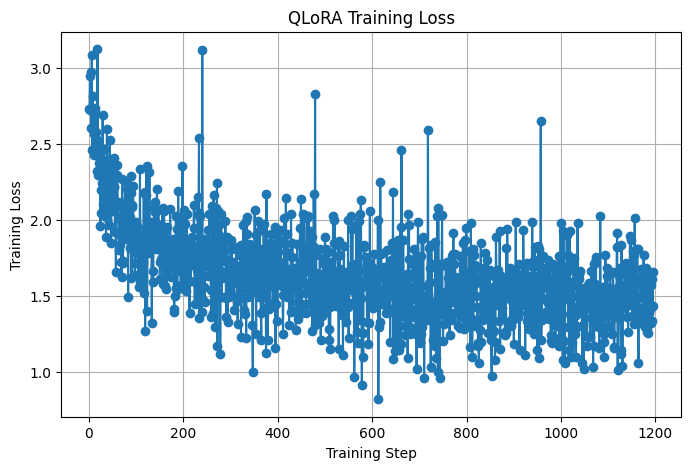


>> [OK] QLoRA loss history analysed.


In [44]:
# Stage 9I: Plot QLoRA training loss

import pandas as pd
import matplotlib.pyplot as plt

qlora_loss_records = [
    {
        "step": entry["step"],
        "loss": entry["loss"]
    }
    for entry in sft_trainer.state.log_history
    if "loss" in entry
]

qlora_loss_df = pd.DataFrame(
    qlora_loss_records
)

print("Stage 9I: QLoRA Loss History")
print("-----------------------------")
print(f"Logged training steps : {len(qlora_loss_df)}")

if len(qlora_loss_df) > 0:

    print(
        f"First logged loss     : "
        f"{qlora_loss_df.iloc[0]['loss']:.4f}"
    )

    print(
        f"Final logged loss     : "
        f"{qlora_loss_df.iloc[-1]['loss']:.4f}"
    )

    print(
        f"Minimum logged loss   : "
        f"{qlora_loss_df['loss'].min():.4f}"
    )

    plt.figure(figsize=(8, 5))

    plt.plot(
        qlora_loss_df["step"],
        qlora_loss_df["loss"],
        marker="o"
    )

    plt.xlabel("Training Step")
    plt.ylabel("Training Loss")
    plt.title("QLoRA Training Loss")
    plt.grid(True)

    plt.show()

print("\n>> [OK] QLoRA loss history analysed.")

### QLoRA Loss History Observation

| Measure | Value |
|---|---|
| Logged training steps | 1,195 (239 per epoch × 5 epochs) |
| First logged loss | 2.7274 |
| Final logged loss | 1.4328 |
| Minimum logged loss | 0.8215 |

**Fast early drop.** The loss starts near 2.7, peaks near 3.1 in the first 20 steps and falls to about 2.0 within roughly the first 100 steps (read from the plot). This is the adapter learning the new format: the "User / Assistant" layout, short direct answers and the end token. The starting loss is higher than CPT's first step (2.1519) because the model had not yet seen this question-and-answer structure.

**Slow improvement, then a plateau.** After about step 100 the loss declines gradually, and from roughly step 500 it moves sideways, with individual steps scattered between about 1.0 and 2.0 around 1.5. The plateau, together with the falling validation loss in Stage 9H, shows that the adapter converged without overfitting within the five epochs.

**Spikes at epoch boundaries.** Four isolated spikes appear at about steps 239, 478, 717 and 956, the ends of epochs 1 to 4 (losses of roughly 3.1, 2.8, 2.6 and 2.65, read from the plot). A likely cause is that 957 examples do not divide evenly into groups of 4 (957 = 4 × 239 + 1), so the last update of an epoch is made from a single example, which gives a much noisier loss. This explanation was not verified in the trainer. The loss returns to normal on the next step each time, and the validation loss was not affected, so the spikes are not a training failure. No spike is visible at the end of epoch 5.

**Noise.** Each point is the loss of one update on only 4 examples, so the line is jagged by about ±0.4. The minimum of 0.8215 and the final value of 1.4328 are single-step values and should not be read as the model's true loss. The trend and the validation loss are the reliable measures.

#### Stage 9J: Save QLoRA Adapter

The trained LoRA adapter is saved separately from the CPT checkpoint.

This preserves the lightweight instruction-tuning parameters while keeping the CPT model as the underlying domain-adapted base model.

The tokenizer is also saved alongside the adapter so that the same tokenization and chat-formatting configuration can be reused during later inference.

In [45]:
# Stage 9J: Save trained QLoRA adapter

from pathlib import Path

QLORA_ADAPTER_DIR = Path(
    "qlora_finance_adapter"
)

sft_trainer.model.save_pretrained(
    QLORA_ADAPTER_DIR
)

qlora_tokenizer.save_pretrained(
    QLORA_ADAPTER_DIR
)

print("Stage 9J: Adapter Checkpoint")
print("-----------------------------")
print(f"Saved directory: {QLORA_ADAPTER_DIR}")

print("\nFiles:")
for file_path in sorted(
    QLORA_ADAPTER_DIR.iterdir()
):
    print(f" - {file_path.name}")

print("\n>> [OK] QLoRA adapter saved.")

Stage 9J: Adapter Checkpoint
-----------------------------
Saved directory: qlora_finance_adapter

Files:
 - README.md
 - adapter_config.json
 - adapter_model.safetensors
 - merges.txt
 - special_tokens_map.json
 - tokenizer.json
 - tokenizer_config.json
 - vocab.json

>> [OK] QLoRA adapter saved.


#### Adapter Checkpoint Observation

The trained LoRA adapter and tokenizer were saved to `qlora_finance_adapter/` (8 files, 10.8 MB in Stage 11B). The adapter weights (`adapter_model.safetensors`, 6.3 MB) are small because they hold only the 1,638,400 LoRA parameters. The adapter is meant to be loaded on top of the saved CPT model in `cpt_model/`.

## Step 8: QLoRA Evaluation

The trained finance adapter is evaluated using the same five instruction prompts used before continued pretraining.

This allows qualitative comparison between:

1. The original pretrained model.
2. The CPT-adapted model.
3. The CPT + QLoRA instruction-tuned model.

The objective is to determine whether QLoRA improves finance-domain instruction following and response quality.

#### Stage 10A: Evaluate the QLoRA Model on Domain Prompts

The trained QLoRA adapter is evaluated using the same five instruction prompts used during the earlier baseline and CPT evaluations.

Using identical prompts allows a direct qualitative comparison between the base model, the CPT-adapted model, and the CPT + QLoRA model.

The evaluation focuses on whether QLoRA improves:

- Relevance to the finance-domain question.
- Instruction-following behaviour.
- Response completeness.
- Reduction of repetition.
- Factual consistency with the domain material.

Generation uses deterministic decoding so that the responses are directly comparable across model stages.

In [46]:
# Stage 10A: Evaluate the trained QLoRA adapter

qlora_model = sft_trainer.model
qlora_model.eval()

# Same instruction prompts as Stage 5D (base) and Stage 7D (CPT)
DOMAIN_PROMPTS = domain_prompts

qlora_outputs = []

print("Stage 10A: Evaluate the trained QLoRA adapter")
print("---------------------------------------------\n")

for prompt in DOMAIN_PROMPTS:
    messages = [{"role": "user", "content": prompt}]
    formatted_prompt = qlora_tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    response = generate_text(qlora_model, qlora_tokenizer, formatted_prompt)
    qlora_outputs.append(response)
    print("PROMPT:")
    print(prompt)
    print("\n>> QLORA RESPONSE:")
    print(response)
    print("-" * 70)

print("\n>> [OK] QLoRA evaluation completed.")


Stage 10A: Evaluate the trained QLoRA adapter
---------------------------------------------

PROMPT:
Explain the risks faced by individual traders in equity derivatives markets.

>> QLORA RESPONSE:
Risk arises from the fact that there is no guarantee of delivery, and therefore a trader cannot rely on his position being realised at the time of settlement.
----------------------------------------------------------------------
PROMPT:
Explain how UPI has contributed to the growth of digital payments in India.

>> QLORA RESPONSE:
UPI is a payment system that allows users to make transactions using their mobile phones, and it was launched on October 15, 2016. It enabled merchants to accept digital payments from customers without requiring physical cash or cheques.
----------------------------------------------------------------------
PROMPT:
What is a buy-back of securities and why might a company conduct one?

>> QLORA RESPONSE:
A buy-back is the process by which an issuer repurchases its 

### QLoRA Evaluation Observation

The same five domain questions used for the baseline and post-CPT checks were asked of the QLoRA model.

**Format is fixed.** Every answer is one or two sentences, in the short direct style of the training data, and every answer ends on its own. The base model rambled into other questions or textbook text. The CPT model continued as exam papers or report fragments, and eight of its ten answers were cut off at the token limit. None of that happens here. This confirms that the model learned both the answer style and when to stop (the end-token check in Stage 9G).

**Content is mixed.**

| Prompt | Assessment |
|---|---|
| 1. Risks for individual derivatives traders | A generic settlement risk ("no guarantee of delivery"). It does not reflect the SEBI study of individual traders and is one sentence for an "explain" question. |
| 2. UPI and digital payments | Describes UPI and says it was "launched on October 15, 2016". The corpus says only that UPI was launched in 2016 (Payment Systems Report, Dec 2024); that exact date does not appear in the cleaned text and should be treated as unverified. It describes UPI and does not explain how it contributed to growth. |
| 3. Buy-back of securities | A correct definition: an issuer repurchases its own outstanding shares from shareholders. It does not answer why a company would do it. |
| 4. Asset reconstruction companies | Vague. It calls ARCs "specialised entities" with "a structured approach to the resolution of stressed assets", then repeats a list of near-synonyms (classification, valuation, assessment, evaluation, appraisal, review). It does not say that ARCs acquire stressed assets from banks. |
| 5. Payments Vision 2025 | A plausible, broadly consistent statement of the vision (seamless, secure, accessible, affordable payments). The document's vision is safe, secure, fast, convenient, accessible and affordable e-payments, built on five goalposts (Integrity, Inclusion, Innovation, Institutionalisation, Internationalisation). The answer names none of these and is general. |

**Comparison.**
- **Base model:** fluent but unfocused, with invented figures and US references.
- **CPT model:** domain vocabulary, but document-style continuation instead of answers.
- **QLoRA model:** concise answers in the right register that stop cleanly, with factual accuracy that is mixed.

**Interpretation.** Instruction tuning solved the behaviour problem, and the answers now read like a regulatory Q&A assistant. It did not solve the accuracy problem: prompt 1 is off target, prompt 2 contains an unverified date, and prompt 4 does not state what ARCs do. Prompts 3 and 5 are correct but incomplete. A 360M-parameter model trained on 957 mostly one-sentence answers picks up the style and some facts, but it cannot be relied on for precise answers. The "why" and "how" parts of questions are often missing, because most training answers are a single sentence. For reliable answers, retrieval from the source documents (RAG) would be the better design, with the fine-tuned model used to phrase the response.

**Limit.** Five prompts are a qualitative check. The validation loss on the 239 held-out pairs (Stage 9H) is the quantitative measure.

#### Stage 10B: Perplexity After QLoRA

Perplexity is measured again on the same 197 held-out blocks (201,531 scored tokens), this time for the CPT model loaded in 4-bit and for the same model with the trained LoRA adapter attached. The comparison shows how much of the change comes from 4-bit loading and how much from QLoRA itself.

In [47]:
# Stage 10B: Perplexity of the CPT + QLoRA model on the same held-out blocks

qlora_model = sft_trainer.model
qlora_model.eval()

# CPT model in 4-bit, adapter switched off (isolates the effect of 4-bit loading)
with qlora_model.disable_adapter():
    cpt4_nll, cpt4_perplexity = calculate_perplexity(
        qlora_model, cpt_holdout_dataset, DEVICE
    )

# CPT model in 4-bit, adapter on (CPT + QLoRA)
qlora_nll, qlora_perplexity = calculate_perplexity(
    qlora_model, cpt_holdout_dataset, DEVICE
)

print("Stage 10B: Perplexity After QLoRA")
print("-" * 35)
print(f"Base model            : {base_perplexity:.4f}")
print(f"CPT model (original)  : {cpt_perplexity:.4f}")
print(f"CPT model (4-bit)     : {cpt4_perplexity:.4f}")
print(f"CPT + QLoRA (4-bit)   : {qlora_perplexity:.4f}")
print(f"\nQLoRA vs CPT (4-bit)  : {qlora_perplexity - cpt4_perplexity:+.4f}")

print("\n>> [OK] Post-QLoRA perplexity measured.")

Stage 10B: Perplexity After QLoRA
-----------------------------------
Base model            : 7.6670
CPT model (original)  : 5.7551
CPT model (4-bit)     : 6.2872
CPT + QLoRA (4-bit)   : 7.0698

QLoRA vs CPT (4-bit)  : +0.7826

>> [OK] Post-QLoRA perplexity measured.


### Post-QLoRA Perplexity Observation

Perplexity was measured on the same held-out finance blocks for all four model states.

| Model | Perplexity | Change vs base |
|---|---|---|
| Base SmolLM2-360M | 7.6670 | n/a |
| CPT model (original precision) | 5.7551 | 24.9% lower |
| CPT model (4-bit) | 6.2872 | 18.0% lower |
| CPT + QLoRA (4-bit, adapter on) | 7.0698 | 7.8% lower |

**Effect of 4-bit loading:** Loading the CPT model in 4-bit raises perplexity from 5.7551 to 6.2872, which is 9.2% higher (+0.5321). That gives back about 28% of the 1.9119 points CPT removed.

**Effect of QLoRA:** With the adapter attached, perplexity rises from 6.2872 to 7.0698, a change of +0.7826 (12.4% higher). Unlike the 4-bit loading, this is a cost of the fine-tuning itself. The adapter was trained on short question-and-answer text, not on continuous finance prose, so it shifts the model away from predicting running document text. This explanation was not tested separately. Of the total rise from the CPT model (5.7551) to the final model (7.0698), about 40% comes from 4-bit loading and about 60% from QLoRA.

**Conclusion:** Compared with the base model, the final CPT + QLoRA model is still 7.8% lower in perplexity, so part of the domain gain from CPT remains after quantisation and fine-tuning. It is a smaller gain than CPT alone (24.9%). The base figure was measured in original precision and the final figure in 4-bit, so the comparison slightly understates the final model's standing against a base model that was also quantised (not measured). QLoRA changes how the model answers at a measurable cost in how well it predicts domain text.

## Step 9: Final Submission Verification

The completed pipeline now contains:

- PDF extraction and cleaning.
- Tokenization and packed CPT dataset construction.
- Base-model architecture inspection and baseline inference.
- Continued pretraining and loss analysis.
- Held-out perplexity and catastrophic-forgetting evaluation.
- Finance-domain instruction dataset creation.
- 4-bit QLoRA fine-tuning using the balanced adapter.
- Post-QLoRA evaluation on the original finance prompts.

The following checks verify that the required submission artifacts were generated successfully.

In [48]:
# Stage 11A: Verify submission artifacts

from pathlib import Path
import json

required_files = {
    "Instruction dataset":
        Path("instruction_dataset.jsonl"),

    "Instruction training split":
        Path("instruction_dataset_train.jsonl"),

    "Instruction evaluation split":
        Path("instruction_dataset_eval.jsonl"),

    "CPT model":
        Path("cpt_model"),

    "QLoRA adapter":
        Path("qlora_finance_adapter"),

    "Packed CPT dataset":
        Path("domain_corpus/packed_dataset.parquet"),
}

print("Stage 11A: Submission Artifact Verification")
print("--------------------------------------------")

all_present = True

for name, path in required_files.items():

    exists = path.exists()

    print(
        f"{name:<30}: "
        f"{'OK' if exists else 'MISSING'}"
    )

    if not exists:
        all_present = False


# Cleaned .txt corpus
cleaned_txt_files = sorted(
    Path("domain_corpus").glob("*.txt")
)

print(
    f"{'Cleaned corpus files':<30}: "
    f"{len(cleaned_txt_files)} found"
)


# Count JSONL records
def count_jsonl(path):
    if not path.exists():
        return 0

    with open(path, encoding="utf-8") as f:
        return sum(
            1 for line in f
            if line.strip()
        )


print("\nInstruction Dataset")
print("-------------------")

print(
    "Full dataset :",
    count_jsonl(
        Path("instruction_dataset.jsonl")
    )
)

print(
    "Training set :",
    count_jsonl(
        Path("instruction_dataset_train.jsonl")
    )
)

print(
    "Evaluation set:",
    count_jsonl(
        Path("instruction_dataset_eval.jsonl")
    )
)


assert len(cleaned_txt_files) == expected_pdf_count

assert count_jsonl(Path("instruction_dataset.jsonl")) == len(final_instruction_df)
assert count_jsonl(Path("instruction_dataset_train.jsonl")) == len(train_records)
assert count_jsonl(Path("instruction_dataset_eval.jsonl")) == len(eval_records)

assert all_present


print(
    "\n>> [OK] Required assignment artifacts "
    "are present."
)

Stage 11A: Submission Artifact Verification
--------------------------------------------
Instruction dataset           : OK
Instruction training split    : OK
Instruction evaluation split  : OK
CPT model                     : OK
QLoRA adapter                 : OK
Packed CPT dataset            : OK
Cleaned corpus files          : 30 found

Instruction Dataset
-------------------
Full dataset : 1196
Training set : 957
Evaluation set: 239

>> [OK] Required assignment artifacts are present.


### Submission Artifact Verification Observation

All required artifacts are present: the full instruction dataset (1,196 examples), the training split (957) and evaluation split (239), the CPT model, the QLoRA adapter, the packed CPT dataset, and 30 cleaned corpus files. The counts match Stage 8E and Stage 9E (957 + 239 = 1,196), and the 30 cleaned files match the 30 source documents.

#### Stage 11B: Output Directories

Every folder and file written by this run is listed with its full path, file count and size. The extracted raw text (`domain_corpus/raw`), the cleaned corpus and packed dataset (`domain_corpus`), the CPT and QLoRA outputs, and the instruction JSONL files should all sit under the working directory, `/home/group157`.

Two entries in the listing need explaining. The raw folder shows 31 files because it holds a 0 B leftover from an earlier run (`RBI - Payment and Settlement Systems and Information Technology 2025-26.txt`) that is not one of the 30 corpus documents. The cleaned folder shows 31 files because it holds the 30 cleaned documents plus the packed Parquet dataset. The two trainer output folders are empty because checkpoint saving was turned off.

In [49]:
# Stage 11B: Output directories and files written by this run

from pathlib import Path


def human_size(num_bytes):
    size = float(num_bytes)
    for unit in ("B", "KB", "MB", "GB"):
        if size < 1024 or unit == "GB":
            return f"{int(size)} B" if unit == "B" else f"{size:,.1f} {unit}"
        size /= 1024


def show_directory(label, path, recursive=False, max_files=20):
    path = Path(path)
    print(f"{label}")
    print(f"  path : {path.resolve()}")
    if not path.exists():
        print("  >> [MISSING]\n")
        return
    pattern = path.rglob("*") if recursive else path.glob("*")
    files = sorted(p for p in pattern if p.is_file())
    total = sum(p.stat().st_size for p in files)
    print(f"  files: {len(files)}   size: {human_size(total)}")
    for p in files[:max_files]:
        print(f"    - {p.relative_to(path)}  ({human_size(p.stat().st_size)})")
    if len(files) > max_files:
        print(f"    ... and {len(files) - max_files} more files")
    print()


print("Stage 11B: Output Directories")
print("-" * 31)
print(f"Working directory: {Path.cwd()}\n")

show_directory("Extracted raw text (Stage 2)",      "domain_corpus/raw")
show_directory("Cleaned corpus + packed dataset",   "domain_corpus")
show_directory("CPT trainer output",                "cpt_output", recursive=True)
show_directory("CPT model (Stage 6F)",              "cpt_model")
show_directory("QLoRA trainer output",              "qlora_training_output", recursive=True)
show_directory("QLoRA adapter (Stage 9J)",          "qlora_finance_adapter")

print("Files in the working directory")
for name in ("instruction_dataset.jsonl", "instruction_dataset_train.jsonl",
             "instruction_dataset_eval.jsonl", "cpt_loss.png"):
    p = Path(name)
    status = human_size(p.stat().st_size) if p.exists() else "MISSING"
    print(f"  - {name}  ({status})")

print("\n>> [OK] Output directories listed.")


Stage 11B: Output Directories
-------------------------------
Working directory: /home/group157

Extracted raw text (Stage 2)
  path : /home/group157/domain_corpus/raw
  files: 31   size: 6.9 MB
    - Profitability of Individual Traders in the Equity Derivatives Segment (FY25–FY26).txt  (138.1 KB)
    - RBI - Annual Report 2023-24.txt  (793.6 KB)
    - RBI - Annual Report 2025-26.txt  (604.2 KB)
    - RBI - Asset Reconstruction Companies Directions 2025.txt  (127.7 KB)
    - RBI - Asset Reconstruction Companies – Credit Information Reporting Directions 2025.txt  (73.3 KB)
    - RBI - Asset Reconstruction Companies – Know Your Customer Directions 2025.txt  (160.5 KB)
    - RBI - Asset Reconstruction Companies – Treatment of Wilful Defaulters and Large Defaulters Directions 2025.txt  (17.0 KB)
    - RBI - Benchmarking Indias Payments Systems - 2022.txt  (139.4 KB)
    - RBI - Digital Lending Guidelines.txt  (20.2 KB)
    - RBI - Digitalisation and Payment Revolution in India 2024.txt  (1

#### Stage 11C: Compress Deliverables

Packs `domain_corpus/*.txt` and `instruction_dataset.jsonl` into one `deliverables.zip` (30 cleaned documents plus the instruction dataset, 31 files, 2088.6 KB in this run) so they can be downloaded from the file browser in a single step.

In [50]:
# Stage 11C: Compress the deliverables into one zip for download
import zipfile
from pathlib import Path

ZIP_NAME = "deliverables.zip"
files = sorted(Path("domain_corpus").glob("*.txt")) + [Path("instruction_dataset.jsonl")]

with zipfile.ZipFile(ZIP_NAME, "w", zipfile.ZIP_DEFLATED) as zf:
    for f in files:
        zf.write(f, arcname=str(f))

print(f"Created {ZIP_NAME}: {Path(ZIP_NAME).stat().st_size/1024:.1f} KB, {len(files)} files")
for f in files:
    print("  ", f)


Created deliverables.zip: 2088.6 KB, 31 files
   domain_corpus/Profitability of Individual Traders in the Equity Derivatives Segment (FY25–FY26).txt
   domain_corpus/RBI - Annual Report 2023-24.txt
   domain_corpus/RBI - Annual Report 2025-26.txt
   domain_corpus/RBI - Asset Reconstruction Companies Directions 2025.txt
   domain_corpus/RBI - Asset Reconstruction Companies – Credit Information Reporting Directions 2025.txt
   domain_corpus/RBI - Asset Reconstruction Companies – Know Your Customer Directions 2025.txt
   domain_corpus/RBI - Asset Reconstruction Companies – Treatment of Wilful Defaulters and Large Defaulters Directions 2025.txt
   domain_corpus/RBI - Benchmarking Indias Payments Systems - 2022.txt
   domain_corpus/RBI - Digital Lending Guidelines.txt
   domain_corpus/RBI - Digitalisation and Payment Revolution in India 2024.txt
   domain_corpus/RBI - Financial Stability Report Dec 2025.txt
   domain_corpus/RBI - Master Circular on IRAC norms on asset classification and pro

### Final Model Comparison

| | Base SmolLM2-360M | After CPT | After CPT + QLoRA |
|---|---|---|---|
| Training data | none (original model) | 30 finance PDFs, 1,747 blocks (1,788,928 tokens), 2 epochs | 957 grounded Q&A pairs (of 1,196; 239 held out), 5 epochs |
| Trainable parameters | n/a | all 361.8M | 1,638,400 adapter parameters (0.45%) |
| Training time | n/a | 9 min 43 s | 29 min 9 s |
| Held-out perplexity | 7.6670 | 5.7551 (24.9% lower) | 7.0698 (7.8% lower than base; 4-bit) |
| Validation loss (instruction data) | n/a | n/a | 1.8165 → 1.6162 |
| Answers the question asked | Partly, with drift into unrelated Q&A | Usually not: continues as exam-style or book-style text | Mostly: one or two sentences, often incomplete |
| Domain vocabulary | Weak, with wrong definitions of buy-back and ARC | Better (RBI and SEBI clause style, payments terms) | Uses domain terms and wording close to the Payments Vision |
| Factual accuracy | Poor | Poor: wrong security receipt and buy-back routes, off-topic content | Mixed: buy-back definition correct, Payments Vision broadly right; generic risk answer, unverified UPI date, vague ARC answer |
| General knowledge retained | Baseline | 2 of 5 prompts correct (sky, energy and France capital fail) | not tested |
| Stops after the answer | No | No (8 of 10 answers cut at the token limit) | Yes (all 5 answers end on their own) |

CPT loaded in 4-bit scores 6.2872, so loading in 4-bit raised perplexity by 0.5321 and QLoRA itself by a further 0.7826. The final figure of 7.0698 is therefore higher than the CPT model's 5.7551 for both reasons.

**Summary:** CPT lowered held-out perplexity by 24.9%, with 4.7% of held-out 16-token windows also present in training. It shifted vocabulary and style toward Indian financial documents, but it did not make the model more accurate, and it weakened the answers to three of five general-knowledge prompts. QLoRA corrected the answer format, from document continuation to a short answer, and taught the model to stop, by keeping the end-of-text token as a training label with a separate pad token. It did this at a cost: perplexity on held-out finance text rose from 6.2872 to 7.0698 against the 4-bit CPT model, leaving the final model 7.8% below the base. The model still gives incomplete or unsupported answers, because 957 mostly one-sentence pairs teach a format and some facts but not full knowledge. Further gains would come from retrieval over the source documents, more varied answer lengths in the instruction data, or a lower learning rate or fewer epochs to reduce the perplexity cost of QLoRA.